# INTRODUCTION

**ANSUR II Databases: Etnik Köken Tahmini**

**1. Genel Bakış:** 
- ANSUR II (Anthropometric Survey of U.S. Army Personnel), 2012'de ABD Ordusu tarafından yürütülen geniş çaplı bir antropometrik (vücut ölçümleri) araştırmasının sonuçlarına dayanmaktadır.
  
**2. Veri Setinin İçeriği:**

- ANSUR II, ordu personelinin vücut ölçümlerini ve etnik köken bilgilerini içerir. Veri kümesi, bireylerin farklı vücut bölümlerinden alınan 100'den fazla ölçümü kapsar. Ölçümler, baş, el, ayak, bacak, kol, göğüs vb. gibi farklı vücut bölümlerine ait detayları içerir.

- Veri seti, doğrudan ölçülen 93 antropometrik ölçüm ve aşağıda açıklanan 15 demografik/idari değişken içerir. 

- Erkek veri seti, toplam 4.082 denekten oluşan bir örnek içerir. 

- ANSUR II Kadın veri seti, toplam 1.986 denekten oluşan bir örnek içerir.

- Ayrıca  antropometrik ve demografik verilere ek olarak, ANSUR II veri tabanı ayrıca Asker katılımcılarının 3B tüm vücut, ayak ve kafa taramalarından oluşur. 
- Bu 3B veriler, ANSUR II katılımcılarının mahremiyetine saygı nedeniyle halka açık değildir. 

**3. Kimler Katıldı?**
- Bu veritabanı, aktif görevdeki ordu personelinin çeşitli etnik gruplarından ve yaş gruplarından temsilcileri içermektedir. Veri kümesinde, hem erkeklerden hem de kadınlardan alınan ölçümler bulunmaktadır.

**4. Ölçüm ve Etnik Köken İlişkisi:**
- Farklı etnik gruplar, genetik ve çevresel faktörlere bağlı olarak farklı vücut yapısına sahip olabilir. Bu, bacak uzunluğu, kafa yapısı, el ve ayak ölçümleri gibi ölçümlerde farklılıklarla gözlemlenebilir.

**5. Modelleme ve Tahmin:**
- Etnik köken tahmini, ANSUR II veri kümesindeki vücut ölçümleri kullanılarak bir sınıflandırma problemi olarak ele alınabilir.
- Kullanılacak algoritma, ölçümler ile etnik köken arasındaki ilişkiyi öğrenir ve yeni verilere uygulanarak etnik köken tahminleri yapabilir.

**6. Projenin Önemi ve Uygulama Alanları:**
- Bu tür bir araştırma, ordu personelinin vücut ölçülerini analiz ederek askeri ekipman, kıyafet ve diğer sistemlerin tasarım ve üretimi için kullanılmaktadır. Doğru ölçümler, askeri personelin rahatlığı, hareket kabiliyeti ve genel güvenliği için kritik öneme sahiptir.

- Ayrıca birçok potansiyel ticari, endüstriyel ve akademik uygulamaya sahiptir.

- Ek olarak belki de Laser okuyucular ve sensörler ile örnek veriyorum bir havaalanından girişte kökeni tespit edilebilir. 

DATA DICT:
https://data.world/datamil/ansur-ii-data-dictionary/workspace/file?filename=ANSUR+II+Databases+Overview.pdf

# Tasks

Keşifsel Veri Analizi (EDA)

- Kütüphaneleri İçe Aktarma

- Veri Kümesi Yükleme

- Verileri Keşfetme

Veri Ön İşleme

- Scaling (gerekirse)

- Değerlendirme amacıyla veri çerçevesini ayırın

Sınıflandırma Algoritmaları

- Logistic Regression Uygulama

- SVM Classifier Uygulama

- Decision Tree Classifier Uygulama

- Random Forest Classifier Uygulama

- XGBoost Classifier Uygula

- Modelleri Karşılaştırın

SMOTE

SHAP

# EDA
- Drop unnecessary colums
- Drop DODRace class if value count below 500 (we assume that our data model can't learn if it is below 500)

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import make_scorer
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay  # New import

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)


## Retrieve data from the following links and create a data frame
- Soldiers Male : https://query.data.world/s/h3pbhckz5ck4rc7qmt2wlknlnn7esr
- Soldiers Female : https://query.data.world/s/sq27zz4hawg32yfxksqwijxmpwmynq

In [2]:
df_male = pd.read_csv('https://query.data.world/s/h3pbhckz5ck4rc7qmt2wlknlnn7esr', encoding='latin-1') 

# Encoding ile UTF-8'e uygun hale getirdik.

In [3]:
df_female= pd.read_csv('https://query.data.world/s/sq27zz4hawg32yfxksqwijxmpwmynq')

## Let's understand the data

- Drop unnecessary colums
- Drop DODRace class if value count below 500 (we assume that our data model can't learn if it is below 500)

In [4]:
df_male.head()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Gender,Date,Installation,Component,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10027,266,1467,337,222,1347,253,202,401,369,274,493,71,319,291,142,979,240,882,619,509,373,1535,291,1074,259,1292,877,607,351,36,71,19,247,802,101,273,349,299,575,477,1136,90,214,193,150,583,206,326,70,332,366,1071,685,422,441,502,560,500,77,391,118,400,436,1447,113,437,273,1151,368,145,928,883,600,1782,1776,1449,1092,610,164,786,491,140,919,1700,501,329,933,240,440,1054,815,175,853,Male,4-Oct-10,Fort Hood,Regular Army,Combat Arms,19D,North Dakota,1,NaN,1,41,71,180,Right hand
1,10032,233,1395,326,220,1293,245,193,394,338,257,479,67,344,320,135,944,232,870,584,468,357,1471,269,1021,253,1244,851,615,376,33,62,18,232,781,98,263,348,289,523,476,1096,86,203,195,146,568,201,334,72,312,356,1046,620,441,447,490,540,488,73,371,131,380,420,1380,118,417,254,1119,353,141,884,868,564,1745,1702,1387,1076,572,169,822,476,120,918,1627,432,316,870,225,371,1054,726,167,815,Male,4-Oct-10,Fort Hood,Regular Army,Combat Support,68W,New York,1,NaN,1,35,68,160,Left hand
2,10033,287,1430,341,230,1327,256,196,427,408,261,544,75,345,330,135,1054,258,901,623,506,412,1501,288,1120,267,1288,854,636,359,40,61,23,237,810,103,270,355,357,575,491,1115,93,220,203,148,573,202,356,70,349,393,1053,665,462,475,496,556,482,72,409,123,403,434,1447,121,431,268,1276,367,167,917,910,604,1867,1735,1438,1105,685,198,807,477,125,918,1678,472,329,964,255,411,1041,929,180,831,Male,4-Oct-10,Fort Hood,Regular Army,Combat Support,68W,New York,2,NaN,2,42,68,205,Left hand
3,10092,234,1347,310,230,1239,262,199,401,359,262,518,73,328,309,143,991,242,821,560,437,395,1423,296,1114,262,1205,769,590,341,39,66,25,272,794,106,267,352,318,593,467,1034,91,217,194,158,576,199,341,68,338,367,986,640,458,461,460,511,452,76,393,106,407,446,1357,118,393,249,1155,330,148,903,848,550,1708,1655,1346,1021,604,180,803,445,127,847,1625,461,315,857,205,399,968,794,176,793,Male,12-Oct-10,Fort Hood,Regular Army,Combat Service Support,88M,Wisconsin,1,NaN,1,31,66,175,Right hand
4,10093,250,1585,372,247,1478,267,224,435,356,263,524,80,340,310,138,1029,275,1080,706,567,425,1684,304,1048,232,1452,1014,682,382,32,56,19,188,814,111,305,399,324,605,550,1279,94,222,218,153,566,197,374,69,332,372,1251,675,481,505,612,666,585,85,458

In [5]:
df_female.head()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Gender,Date,Installation,Component,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10037,231,1282,301,204,1180,222,177,373,315,263,466,65,338,301,141,1011,223,836,587,476,360,1336,274,922,245,1095,759,557,310,35,65,16,220,713,91,246,316,265,517,432,1028,75,182,184,141,548,191,314,69,345,388,966,645,363,399,435,496,447,55,404,118,335,368,1268,113,362,235,1062,327,148,803,809,513,1647,1560,1280,1013,622,174,736,430,110,844,1488,406,295,850,217,345,942,657,152,756,Female,5-Oct-10,Fort Hood,Regular Army,Combat Support,92Y,Germany,2,NaN,2,26,61,142,Right hand
1,10038,194,1379,320,207,1292,225,178,372,272,250,430,64,294,270,126,893,186,900,583,483,350,1440,261,839,206,1234,835,549,329,32,60,23,208,726,91,249,341,247,468,463,1117,78,187,189,138,535,180,307,60,315,335,1048,595,340,375,483,532,492,69,334,115,302,345,1389,110,426,259,1014,346,142,835,810,575,1751,1665,1372,1107,524,152,771,475,125,901,1470,422,254,708,168,329,1032,534,155,815,Female,5-Oct-10,Fort Hood,Regular Army,Combat Service Support,25U,California,3,Mexican,3,21,64,120,Right hand
2,10042,183,1369,329,233,1271,237,196,397,300,276,450,69,309,270,128,987,204,861,583,466,384,1451,287,874,223,1226,821,643,374,36,65,26,204,790,100,265,343,262,488,469,1060,84,198,195,146,588,207,331,70,356,399,1043,655,345,399,470,530,469,64,401,135,325,369,1414,122,398,258,1049,362,164,904,855,568,1779,1711,1383,1089,577,164,814,458,129,882,1542,419,269,727,159,367,1035,663,162,799,Female,5-Oct-10,Fort Hood,Regular Army,Combat Service Support,35D,Texas,1,NaN,1,23,68,147,Right hand
3,10043,261,1356,306,214,1250,240,188,384,364,276,484,68,340,294,144,1012,253,897,599,471,372,1430,269,1008,285,1170,804,640,351,38,62,22,244,775,97,265,331,309,529,455,1069,80,192,186,153,593,206,332,68,337,402,1029,655,392,435,469,520,478,67,402,118,357,386,1329,115,394,250,1121,333,157,875,815,536,1708,1660,1358,1065,679,187,736,463,125,866,1627,451,302,923,235,371,999,782,173,818,Female,5-Oct-10,Fort Hood,Regular Army,Combat Service Support,25U,District of Columbia,8,Caribbean Islander,2,22,66,175,Right hand
4,10051,309,1303,308,214,1210,217,182,378,320,336,525,67,300,295,135,1281,284,811,607,467,433,1362,305,1089,290,1112,726,686,356,34,65,18,233,732,88,247,339,260,596,447,1039,78,183,187,140,522,181,308,63

In [6]:
print(df_male.shape)
print(df_female.shape)

# İkisininde de eşit sayıda 108 feature var

(4082, 108)
(1986, 108)


In [7]:
data = pd.concat([df_male,df_female], axis=0, ignore_index=True)
data.head()

# ignore_index=True ile, yeni oluşturulan DataFrame'de indeksleri sıfırdan başlayarak yeniden oluşturuyoruz 

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Gender,Date,Installation,Component,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference,SubjectId
0,10027.0,266,1467,337,222,1347,253,202,401,369,274,493,71,319,291,142,979,240,882,619,509,373,1535,291,1074,259,1292,877,607,351,36,71,19,247,802,101,273,349,299,575,477,1136,90,214,193,150,583,206,326,70,332,366,1071,685,422,441,502,560,500,77,391,118,400,436,1447,113,437,273,1151,368,145,928,883,600,1782,1776,1449,1092,610,164,786,491,140,919,1700,501,329,933,240,440,1054,815,175,853,Male,4-Oct-10,Fort Hood,Regular Army,Combat Arms,19D,North Dakota,1,NaN,1,41,71,180,Right hand,NaN
1,10032.0,233,1395,326,220,1293,245,193,394,338,257,479,67,344,320,135,944,232,870,584,468,357,1471,269,1021,253,1244,851,615,376,33,62,18,232,781,98,263,348,289,523,476,1096,86,203,195,146,568,201,334,72,312,356,1046,620,441,447,490,540,488,73,371,131,380,420,1380,118,417,254,1119,353,141,884,868,564,1745,1702,1387,1076,572,169,822,476,120,918,1627,432,316,870,225,371,1054,726,167,815,Male,4-Oct-10,Fort Hood,Regular Army,Combat Support,68W,New York,1,NaN,1,35,68,160,Left hand,NaN
2,10033.0,287,1430,341,230,1327,256,196,427,408,261,544,75,345,330,135,1054,258,901,623,506,412,1501,288,1120,267,1288,854,636,359,40,61,23,237,810,103,270,355,357,575,491,1115,93,220,203,148,573,202,356,70,349,393,1053,665,462,475,496,556,482,72,409,123,403,434,1447,121,431,268,1276,367,167,917,910,604,1867,1735,1438,1105,685,198,807,477,125,918,1678,472,329,964,255,411,1041,929,180,831,Male,4-Oct-10,Fort Hood,Regular Army,Combat Support,68W,New York,2,NaN,2,42,68,205,Left hand,NaN
3,10092.0,234,1347,310,230,1239,262,199,401,359,262,518,73,328,309,143,991,242,821,560,437,395,1423,296,1114,262,1205,769,590,341,39,66,25,272,794,106,267,352,318,593,467,1034,91,217,194,158,576,199,341,68,338,367,986,640,458,461,460,511,452,76,393,106,407,446,1357,118,393,249,1155,330,148,903,848,550,1708,1655,1346,1021,604,180,803,445,127,847,1625,461,315,857,205,399,968,794,176,793,Male,12-Oct-10,Fort Hood,Regular Army,Combat Service Support,88M,Wisconsin,1,NaN,1,31,66,175,Right hand,NaN
4,10093.0,250,1585,372,247,1478,267,224,435,356,263,524,80,340,310,138,1029,275,1080,706,567,425,1684,304,1048,232,1452,1014,682,382,32,56,19,188,814,111,305,399,324,605,550,1279,94,222,218,153,566,197,374,69,332,372

In [8]:
data.shape   

# SubjectId ve subjectid sütunlarının isimleri farklı olduğundan sütun sayısın bir tane arttı, iki ayrı sütun oluştu
# Farklı bir yaklaşım olarak sütun isimlerini aynı yapıp devam edilebilir

(6068, 109)

In [9]:
data.info(verbose=True)  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6068 entries, 0 to 6067
Data columns (total 109 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    subjectid                       float64
 1    abdominalextensiondepthsitting  int64  
 2    acromialheight                  int64  
 3    acromionradialelength           int64  
 4    anklecircumference              int64  
 5    axillaheight                    int64  
 6    balloffootcircumference         int64  
 7    balloffootlength                int64  
 8    biacromialbreadth               int64  
 9    bicepscircumferenceflexed       int64  
 10   bicristalbreadth                int64  
 11   bideltoidbreadth                int64  
 12   bimalleolarbreadth              int64  
 13   bitragionchinarc                int64  
 14   bitragionsubmandibulararc       int64  
 15   bizygomaticbreadth              int64  
 16   buttockcircumference            int64  
 17   buttockdepth

missing value var

In [10]:
data.isnull().sum().any()

True

In [11]:
data.duplicated().sum()

0

DODRace
1    3792
2    1298
3     679
4     188
6      59
5      49
8       3
Name: count, dtype: int64


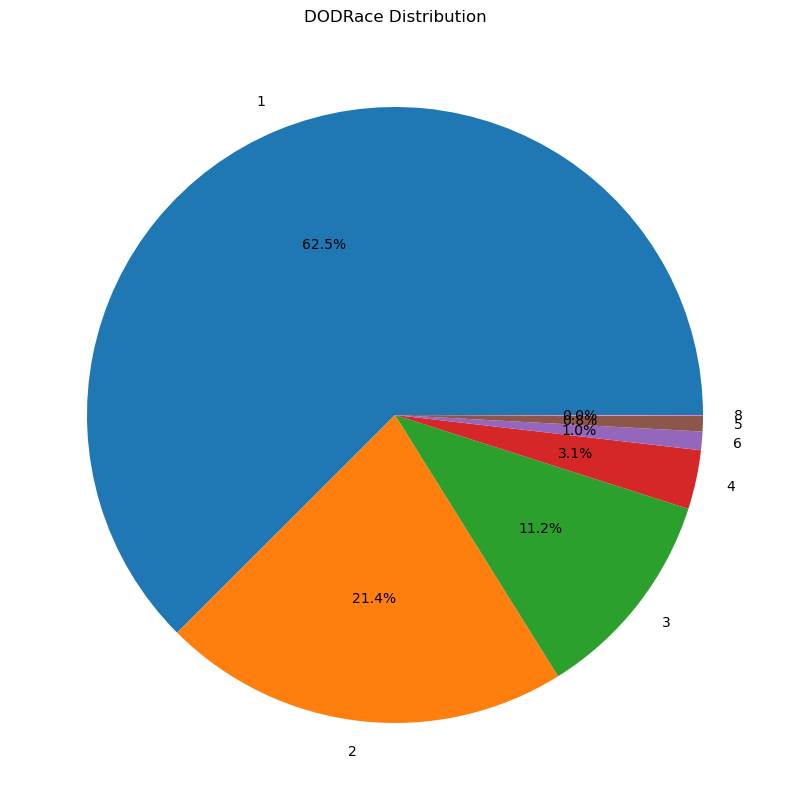

In [12]:
race_counts = data["DODRace"].value_counts()
print(race_counts)
plt.figure(figsize=(10, 10))
plt.pie(race_counts, labels=race_counts.index, autopct='%1.1f%%')
plt.title('DODRace Distribution')
plt.show()

# Sınıf sayısı 500'den az olanları silebilir diye düşünmüştük
# 1 = White
# 2 = Black
# 3 = Hispanic

In [13]:
drop_list =[]
for col in data:
  if data[col].isnull().sum()>1800:
    print(f"{col} = {data[col].isnull().sum()}")
    drop_list.append(col)
  
  
drop_list 

# Missing value sayisi 1800'den fazla olan sütunları görmek icin bir fonksiyon tanimladik; sonra bunlari sildik
# Subject ID lerdeki missing value sayısı sütun isimlerinin uyuşmamasından kaynaklı

subjectid = 1986
Ethnicity = 4647
SubjectId = 4082


['subjectid', 'Ethnicity', 'SubjectId']

In [14]:
data.drop(drop_list, axis=1, inplace=True)

In [15]:
data.isnull().sum().any()

False

In [16]:
data.shape

# Feature sayım 109'dan 106 ya düştü

(6068, 106)

In [17]:
# Encoding için bir fikir sahibi olmak için object olan sütunlardaki unique değerlere bakıyoruz

for col in data.select_dtypes("object"):
  print(f"{col} has {data[col].nunique()} unique value") 

# Burdaki object sutunlardan bazilarini gereksiz oldugu icin silecegiz. 
# SubjectBirthLocation cok fazla unique degere sahip fakat ozellikle Shap analizinde 
# sonuclari olumlu yonde etkileyecegi icin bunu tutacagiz.
# Kısaca gender, SubjectsBirthLocation (doğum yeri hispanic için önemli), WritingPreference dışındakileri düşeceğim.

Gender has 2 unique value
Date has 253 unique value
Installation has 12 unique value
Component has 3 unique value
Branch has 3 unique value
PrimaryMOS has 285 unique value
SubjectsBirthLocation has 152 unique value
WritingPreference has 3 unique value


In [18]:
# target sütunumuzdaki unique değerlere bakalım

data.DODRace.unique()

array([1, 2, 3, 4, 5, 6, 8], dtype=int64)

In [19]:
data["DODRace"] = data.DODRace.map({
    1: "White",
    2: "Black",
    3: "Hispanic",
    4: "Asian",
    5: "Native American",
    6: "Pacific Islander",
    8: "Other"
})

# Target sütunumuzdaki rakamların ne anlama geldiğini daha iyi anlayabilmek için isimlerini degiştiriyoruz

In [20]:
data.groupby(["Component"])["DODRace"].value_counts() 

# "Component" ve "Branch" sutunlarini silmeye karar verdik ama yine de dagilima bir etkisi var mi diye bakıyoruz.
# Bazi birliklerde Hispanic' lerin sayisi daha fazla ise katkisi olabilirdi 
# Datada hispanic sayisi az oldugu icin onu onemsiyoruz. 
# Fakat dagilimin yaklaşık olarak esit oldugunu gorduk. Bu yuzden silecegiz.

Component            DODRace         
Army National Guard  White               1855
                     Black                499
                     Hispanic             253
                     Asian                 60
                     Native American       24
                     Pacific Islander      17
Army Reserve         White                114
                     Black                 52
                     Hispanic              41
                     Asian                  9
                     Pacific Islander       3
                     Native American        1
Regular Army         White               1823
                     Black                747
                     Hispanic             385
                     Asian                119
                     Pacific Islander      39
                     Native American       24
                     Other                  3
Name: count, dtype: int64

In [21]:
data.groupby(["Component", "Branch"])["DODRace"].value_counts() 

Component            Branch                  DODRace         
Army National Guard  Combat Arms             White               623
                                             Black                79
                                             Hispanic             74
                                             Asian                18
                                             Native American       9
                                             Pacific Islander      4
                     Combat Service Support  White               917
                                             Black               312
                                             Hispanic            142
                                             Asian                33
                                             Pacific Islander     11
                                             Native American      10
                     Combat Support          White               315
                                         

Gereksiz veya fazla olan feature' lari dusurelim :

In [22]:
drop_list1 = [
    "Date", "Installation", "Component", "Branch", "PrimaryMOS",
    "Weightlbs", "Heightin",   
]

data.drop(drop_list1, axis=1, inplace=True)

In [23]:
data.columns

Index(['abdominalextensiondepthsitting', 'acromialheight', 'acromionradialelength', 'anklecircumference', 'axillaheight', 'balloffootcircumference', 'balloffootlength', 'biacromialbreadth', 'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth', 'bimalleolarbreadth', 'bitragionchinarc', 'bitragionsubmandibulararc', 'bizygomaticbreadth', 'buttockcircumference', 'buttockdepth', 'buttockheight', 'buttockkneelength', 'buttockpopliteallength', 'calfcircumference', 'cervicaleheight', 'chestbreadth', 'chestcircumference', 'chestdepth', 'chestheight', 'crotchheight', 'crotchlengthomphalion', 'crotchlengthposterioromphalion', 'earbreadth', 'earlength', 'earprotrusion', 'elbowrestheight', 'eyeheightsitting', 'footbreadthhorizontal', 'footlength', 'forearmcenterofgriplength', 'forearmcircumferenceflexed', 'forearmforearmbreadth', 'forearmhandlength', 'functionalleglength', 'handbreadth', 'handcircumference', 'handlength', 'headbreadth', 'headcircumference', 'headlength',
       'heel

In [24]:
data.SubjectNumericRace.value_counts()

# Görüldüğü üzere SubjectNumericRace de çok fazla unique veri var. 
# Bunları kendileri vermişti ve çok detaylı söylediklerinden ve datam içinde target label imi tarif ettiğinden düşüreceğim

SubjectNumericRace
1        3561
2        1026
3         541
31        160
51        126
8         116
4         109
21         60
6          59
41         46
61         35
23         34
28         26
251        20
5          18
18         18
25         14
351        10
38          9
64          8
62          8
35          8
42          7
63          7
231         6
43          5
235         4
218         3
651         2
2351        2
318         2
641         2
451         2
423         2
431         2
2518        2
48          1
631         1
4251        1
428         1
238         1
358         1
425         1
42351       1
Name: count, dtype: int64

In [25]:
data.drop("SubjectNumericRace",axis=1,inplace=True)

# Askerlerin etnik kökeni ile cok detayli bilgi veren "SubjectNumericRace" sutununu da dusurmeye karar verdik.

In [26]:
data.DODRace.value_counts()

# Datamızda EDA kısmı ile ilgili şöyle bir bilgi verilmişti. 500' un altindakileri sil demişti. 
# Biz de silmeye karar vermistik. Bunu target label' a da uyguluyoruz. 
# Yani target' ta sadece White, Black ve Hispanic kalacak.

DODRace
White               3792
Black               1298
Hispanic             679
Asian                188
Pacific Islander      59
Native American       49
Other                  3
Name: count, dtype: int64

In [27]:
data = data[(data["DODRace"] == "White") | (data["DODRace"] == "Black") | (data["DODRace"] == "Hispanic")]
data

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Gender,SubjectsBirthLocation,DODRace,Age,WritingPreference
0,266,1467,337,222,1347,253,202,401,369,274,493,71,319,291,142,979,240,882,619,509,373,1535,291,1074,259,1292,877,607,351,36,71,19,247,802,101,273,349,299,575,477,1136,90,214,193,150,583,206,326,70,332,366,1071,685,422,441,502,560,500,77,391,118,400,436,1447,113,437,273,1151,368,145,928,883,600,1782,1776,1449,1092,610,164,786,491,140,919,1700,501,329,933,240,440,1054,815,175,853,Male,North Dakota,White,41,Right hand
1,233,1395,326,220,1293,245,193,394,338,257,479,67,344,320,135,944,232,870,584,468,357,1471,269,1021,253,1244,851,615,376,33,62,18,232,781,98,263,348,289,523,476,1096,86,203,195,146,568,201,334,72,312,356,1046,620,441,447,490,540,488,73,371,131,380,420,1380,118,417,254,1119,353,141,884,868,564,1745,1702,1387,1076,572,169,822,476,120,918,1627,432,316,870,225,371,1054,726,167,815,Male,New York,White,35,Left hand
2,287,1430,341,230,1327,256,196,427,408,261,544,75,345,330,135,1054,258,901,623,506,412,1501,288,1120,267,1288,854,636,359,40,61,23,237,810,103,270,355,357,575,491,1115,93,220,203,148,573,202,356,70,349,393,1053,665,462,475,496,556,482,72,409,123,403,434,1447,121,431,268,1276,367,167,917,910,604,1867,1735,1438,1105,685,198,807,477,125,918,1678,472,329,964,255,411,1041,929,180,831,Male,New York,Black,42,Left hand
3,234,1347,310,230,1239,262,199,401,359,262,518,73,328,309,143,991,242,821,560,437,395,1423,296,1114,262,1205,769,590,341,39,66,25,272,794,106,267,352,318,593,467,1034,91,217,194,158,576,199,341,68,338,367,986,640,458,461,460,511,452,76,393,106,407,446,1357,118,393,249,1155,330,148,903,848,550,1708,1655,1346,1021,604,180,803,445,127,847,1625,461,315,857,205,399,968,794,176,793,Male,Wisconsin,White,31,Right hand
4,250,1585,372,247,1478,267,224,435,356,263,524,80,340,310,138,1029,275,1080,706,567,425,1684,304,1048,232,1452,1014,682,382,32,56,19,188,814,111,305,399,324,605,550,1279,94,222,218,153,566,197,374,69,332,372,1251,675,481,505,612,666,585,85,458,135,398,430,1572,132,523,302,1231,400,180,919,995,641,2035,1914,1596,1292,672,194,962,584,122,1090,1679,467,303,868,214,379,1245,946,188,954,Male,North Carolina,Black,21,Right hand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [28]:
data.DODRace.value_counts()

DODRace
White       3792
Black       1298
Hispanic     679
Name: count, dtype: int64

In [29]:
data.reset_index(drop=True, inplace=True)  # Sildigimiz degerlerden dolayi datayi bastan indexlememiz gerekir.

In [30]:
data

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Gender,SubjectsBirthLocation,DODRace,Age,WritingPreference
0,266,1467,337,222,1347,253,202,401,369,274,493,71,319,291,142,979,240,882,619,509,373,1535,291,1074,259,1292,877,607,351,36,71,19,247,802,101,273,349,299,575,477,1136,90,214,193,150,583,206,326,70,332,366,1071,685,422,441,502,560,500,77,391,118,400,436,1447,113,437,273,1151,368,145,928,883,600,1782,1776,1449,1092,610,164,786,491,140,919,1700,501,329,933,240,440,1054,815,175,853,Male,North Dakota,White,41,Right hand
1,233,1395,326,220,1293,245,193,394,338,257,479,67,344,320,135,944,232,870,584,468,357,1471,269,1021,253,1244,851,615,376,33,62,18,232,781,98,263,348,289,523,476,1096,86,203,195,146,568,201,334,72,312,356,1046,620,441,447,490,540,488,73,371,131,380,420,1380,118,417,254,1119,353,141,884,868,564,1745,1702,1387,1076,572,169,822,476,120,918,1627,432,316,870,225,371,1054,726,167,815,Male,New York,White,35,Left hand
2,287,1430,341,230,1327,256,196,427,408,261,544,75,345,330,135,1054,258,901,623,506,412,1501,288,1120,267,1288,854,636,359,40,61,23,237,810,103,270,355,357,575,491,1115,93,220,203,148,573,202,356,70,349,393,1053,665,462,475,496,556,482,72,409,123,403,434,1447,121,431,268,1276,367,167,917,910,604,1867,1735,1438,1105,685,198,807,477,125,918,1678,472,329,964,255,411,1041,929,180,831,Male,New York,Black,42,Left hand
3,234,1347,310,230,1239,262,199,401,359,262,518,73,328,309,143,991,242,821,560,437,395,1423,296,1114,262,1205,769,590,341,39,66,25,272,794,106,267,352,318,593,467,1034,91,217,194,158,576,199,341,68,338,367,986,640,458,461,460,511,452,76,393,106,407,446,1357,118,393,249,1155,330,148,903,848,550,1708,1655,1346,1021,604,180,803,445,127,847,1625,461,315,857,205,399,968,794,176,793,Male,Wisconsin,White,31,Right hand
4,250,1585,372,247,1478,267,224,435,356,263,524,80,340,310,138,1029,275,1080,706,567,425,1684,304,1048,232,1452,1014,682,382,32,56,19,188,814,111,305,399,324,605,550,1279,94,222,218,153,566,197,374,69,332,372,1251,675,481,505,612,666,585,85,458,135,398,430,1572,132,523,302,1231,400,180,919,995,641,2035,1914,1596,1292,672,194,962,584,122,1090,1679,467,303,868,214,379,1245,946,188,954,Male,North Carolina,Black,21,Right hand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

<Axes: >

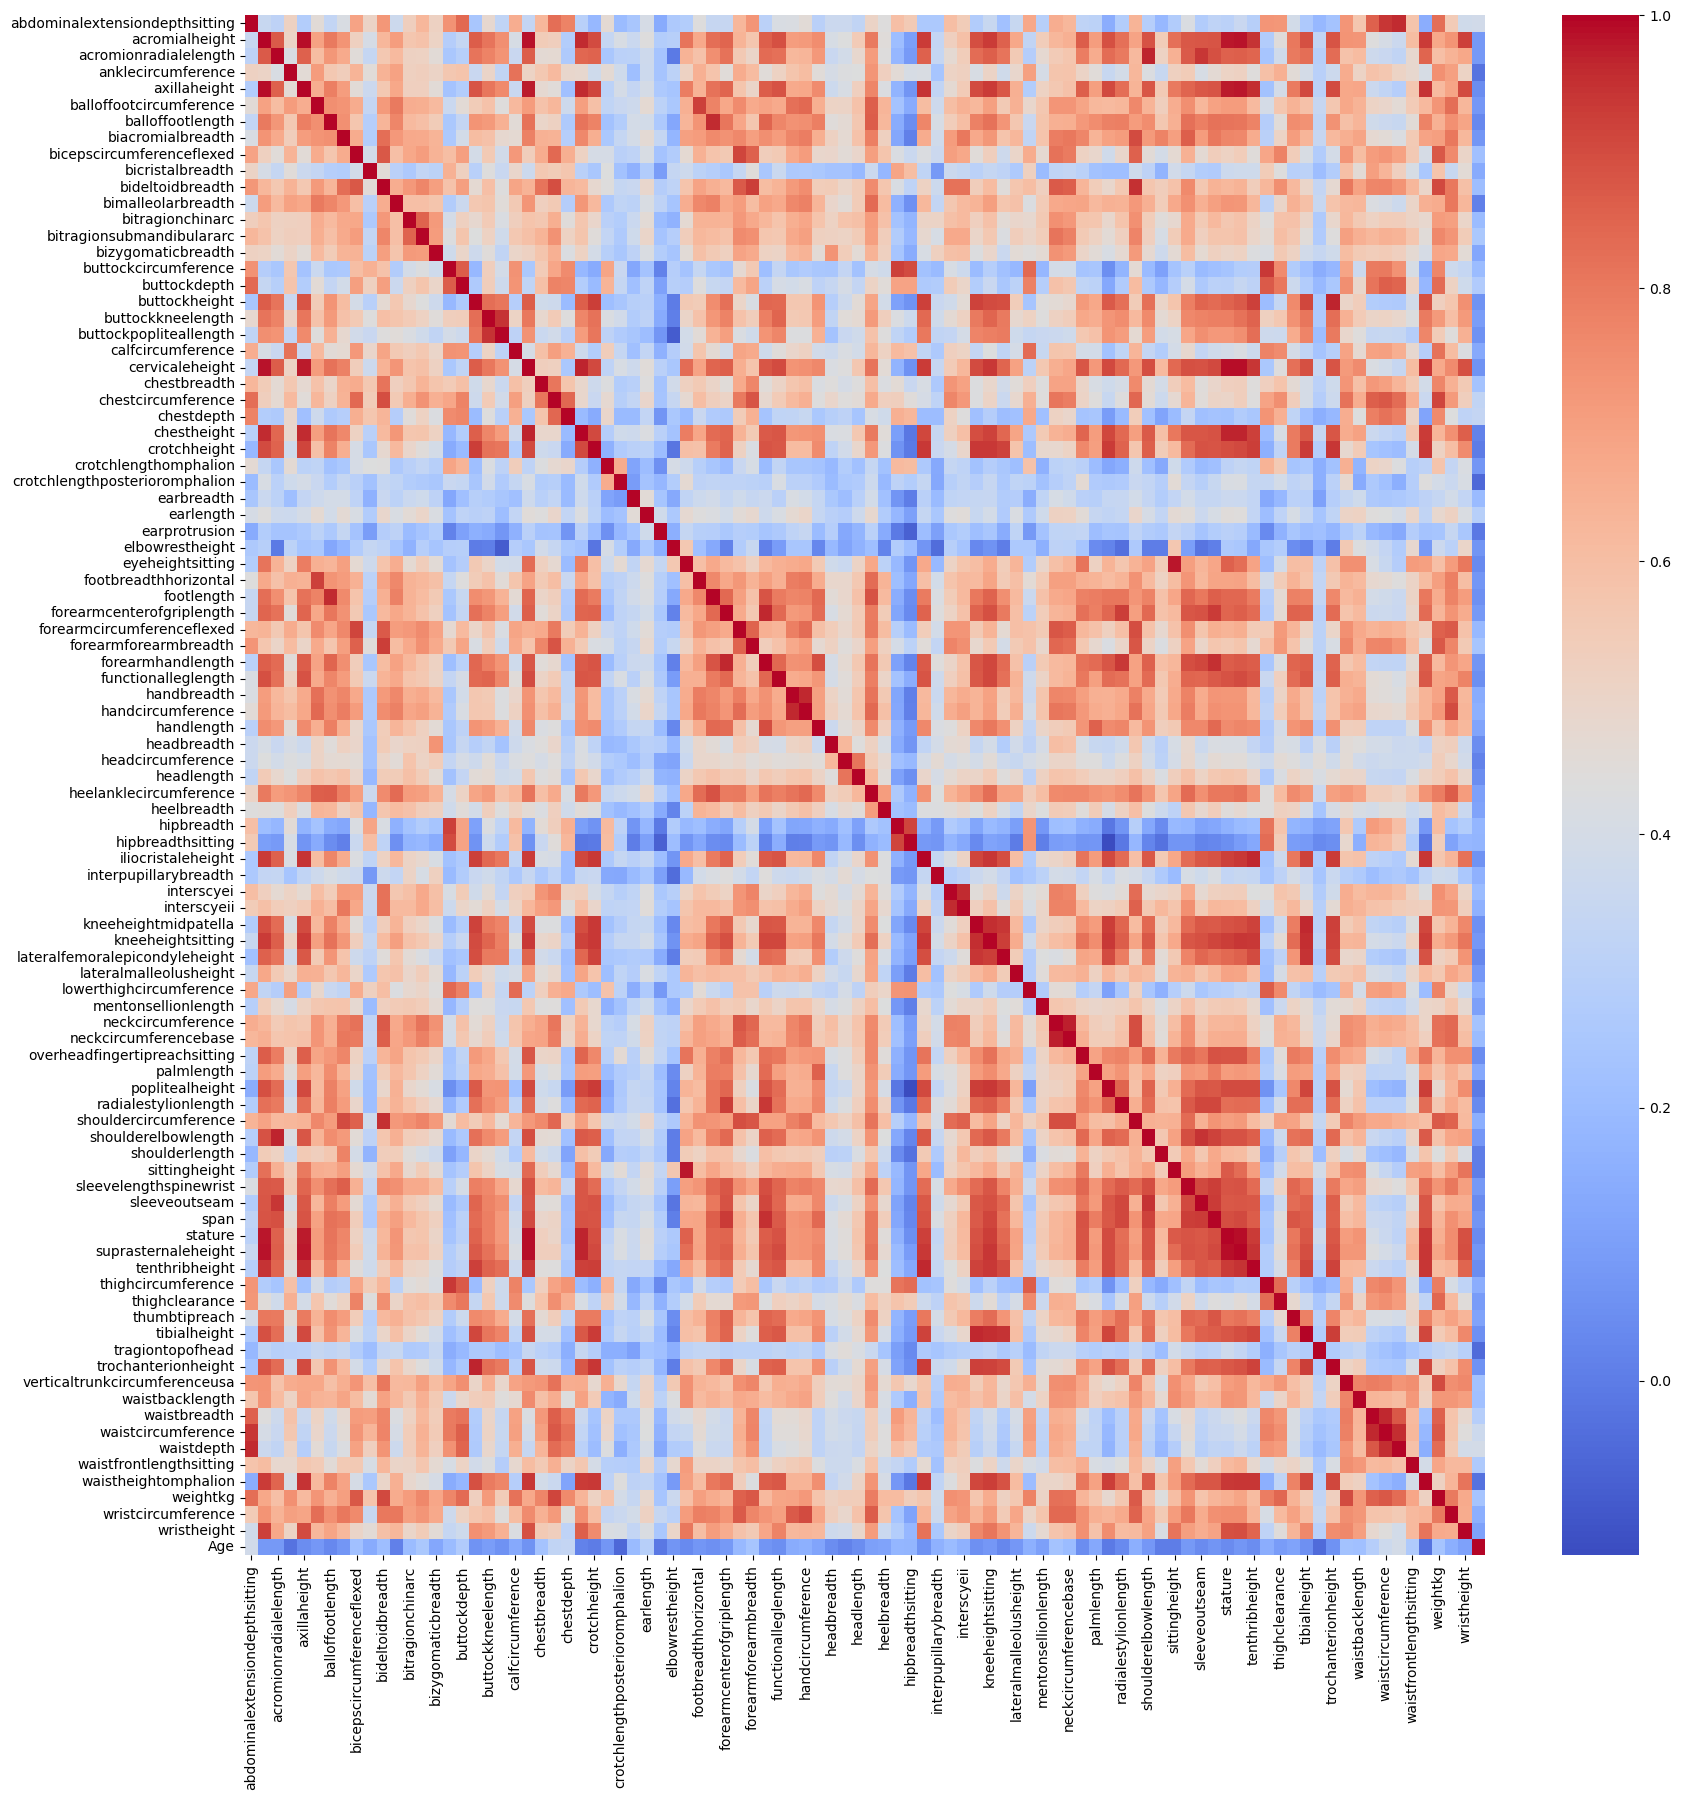

In [31]:
numerical_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(20,20))
sns.heatmap(numerical_data.corr(), cmap="coolwarm")

# heatmap' te degerleri cok ayrintili analiz edemesek de yogun kirmizi renkli olan feature' lar arasinda 
# multicollinearity oldugunu gorebiliyoruz. 
# Fakat biz multicollinearity sorunu ile ugrasmayacagiz. 
# Cunku Logistic Regression arka planda regularization ile bu sorunu cozecek. 
# Multicollinearity' nin feature importance' a cok etkisi var. 
# SVC model distance base bir model oldugu icin o modelde feature importance elde edemeyecegiz.
# Bu yuzden multicollinearity bizim icin bir sorun teskil etmiyor. 

In [32]:
# Birbirleriyle cok fazla multicollinearity iliskisi olan feature' lari tespit etmek icin bir fonksiyon yazdik.
# Sütunlar arasındaki korelasyonları hesaplar ve bu korelasyonlar 0.9 ile 1 arasında veya -0.9 ile -1 arasında olan
# sütun çiftlerini bulur. 

df_temp = numerical_data.corr()

feature =[]
collinear=[]
for col in df_temp.columns:
    for i in df_temp.index:
        if (df_temp[col][i]> .9 and df_temp[col][i] < 1) or (df_temp[col][i]< -.9 and df_temp[col][i] > -1) :
                feature.append(col)
                collinear.append(i)

hangi featurelerin hangileri ile multicolinetary olduğunu görmüş oluyoruz.

In [33]:
# hangi featurelerin birbiriyle ile multicolinetary sergilediğini görmüş oluyoruz.

my_dict = {"feature":feature, "collinear":collinear}
df_col = pd.DataFrame(my_dict)
df_col

# "Hangi fueature digerleri ile en fazla multicollinearity?" bunu goruyoruz. 
# "kneeheightsitting" gibi diger feature' larla en cok multicollinearity' si olan feature' lar tutulup,
# multicollinearity sorunu yasadigi feature' lar silinerek de yola devam edilebilirdi.
# Bu sekilde yola daha az feature ile devam edilip complexity de azaltilabilirdi. 
# Modellerimiz multicollinearity sorun etmedigi icin ve Shap' da feature selection yapacagimiz icin bu asamaya gerek yok.

,feature,collinear
0,abdominalextensiondepthsitting,waistcircumference
1,abdominalextensiondepthsitting,waistdepth
2,acromialheight,axillaheight
3,acromialheight,cervicaleheight
4,acromialheight,chestheight
5,acromialheight,iliocristaleheight
6,acromialheight,kneeheightsitting
7,acromialheight,stature
8,acromialheight,suprasternaleheight
9,acromialheight,tenthribheight


In [34]:
df_col.value_counts("feature")   

feature
kneeheightsitting                 19
iliocristaleheight                15
tenthribheight                    15
axillaheight                      14
waistheightomphalion              14
crotchheight                      14
cervicaleheight                   14
kneeheightmidpatella              12
suprasternaleheight               12
chestheight                       11
tibialheight                      11
acromialheight                    10
poplitealheight                   10
span                               9
trochanterionheight                9
stature                            9
lateralfemoralepicondyleheight     7
buttockheight                      7
sleeveoutseam                      6
forearmhandlength                  5
radialestylionlength               4
shoulderelbowlength                3
functionalleglength                3
waistcircumference                 3
bideltoidbreadth                   3
weightkg                           3
forearmcenterofgriplength     

# DATA Preprocessing
- In this step we divide our data to X(Features) and y(Target) then ,
- To train and evaluation purposes we create train and test sets,
- Lastly, scale our data if features not in same scale. Why?

In [35]:
X = data.drop(columns= ["DODRace"])
y = data.DODRace

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify = y)

# stratify=y, hedef değişken (y) üzerindeki sınıf dağılımının, oluşturulan eğitim ve test setlerinde de korunmasını sağlar
# özellikle dengesiz veri setleri için yararlıdır. Dengesiz bir veri setinde, bir sınıf diğer sınıflardan çok daha fazla
# örnek içerebilir. Bu durumda, stratify=y kullanmak, modelin tüm sınıfları adil bir şekilde öğrenmesine yardımcı olabilir

In [37]:
print("Train features shape : ", X_train.shape)
print("Train target shape   : ", y_train.shape)
print("Test features shape  : ", X_test.shape)
print("Test target shape    : ", y_test.shape)

Train features shape :  (4615, 97)
Train target shape   :  (4615,)
Test features shape  :  (1154, 97)
Test target shape    :  (1154,)


In [38]:
X.shape

(5769, 97)

# Modelling
- Fit the model with train dataset
- Get predict from vanilla model on both train and test sets to examine if there is over/underfitting   
- Apply GridseachCV for both hyperparemeter tuning and sanity test of our model.
- Use hyperparameters that you find from gridsearch and make final prediction and evaluate the result according to chosen metric.

## 1. Logistic model

### Vanilla Logistic Model

In [39]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [40]:
cat = X_train.select_dtypes("object").columns
cat 

Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object')

Bu kod, scikit-learn kütüphanesinin make_column_transformer fonksiyonunu kullanarak karmaşık bir veri ön işleme işlemi oluşturur. İki farklı türde veri dönüşümü yapılır:

1. **One-Hot Encoding**: Kategorik sütunlar (cat değişkeni ile belirtilmiş) için One-Hot Encoding uygulanır. **handle_unknown="ignore"** parametresi, eğitim verisinde olmayan yeni kategorilerin görmezden gelinmesini sağlar. **sparse=False** parametresi, dönüşüm sonucunun yoğun bir matris (dense array) olarak döndürülmesini sağlar.

2. **MinMax Scaling**: **remainder=MinMaxScaler()** parametresi, One-Hot Encoding uygulanmayan diğer tüm sütunlar için Min-Max ölçekleme yapılacağını belirtir. Bu, her bir özelliği 0 ile 1 arasında bir değere ölçekler. Feature importance yaparken mutlaka scale yapılmalıydı bu sebeple yapıyorum.

Bu iki dönüşümü bir araya getiren make_column_transformer, bir **"sütun dönüştürücü" (column_trans)** oluşturur. Bu dönüştürücü, farklı sütunlara farklı ön işleme adımları uygulayabilir, bu da veri setlerinin karmaşık yapısını daha iyi ele almayı sağlar.

Bu oluşturulan column_trans nesnesi, daha sonra bir model eğitilirken veya bir veri seti üzerinde tahminler yapılırken kullanılabilir. Örneğin, bu dönüştürücüyü bir pipeline içerisinde kullanabilirsiniz:

In [41]:
column_trans = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
    remainder=MinMaxScaler()
)

Bu kodda iki ana bileşen var:

1. **column_trans** adlı bir dönüştürücü: Bu dönüştürücü, kategorik verileri "one-hot encoding" yaparak sayısal bir forma dönüştürüyor. Aynı zamanda, kategorik olmayan diğer sayısal sütunları da 0 ile 1 arasına ölçekliyor (MinMax ölçekleme).

2. **LogisticRegression** adlı bir model: Bu model, lojistik regresyon algoritmasını kullanarak sınıflandırma yapacak. Model, sınıflar arasında dengesizlik varsa bunu dikkate alacak (class_weight='balanced'). Maksimum 10,000 iterasyon yapacak ve rastgelelik için 101 numarasını kullanacak (random_state=101).

Bu iki bileşen, genellikle bir "pipeline" içinde bir araya getirilir. Pipeline, ilk olarak veriyi column_trans ile ön işler, yani kategorik verileri sayısal forma dönüştürür ve sayısal sütunları ölçekler. Sonra, bu ön işlenmiş veri üzerinde lojistik regresyon modelini eğitir.

Bu pipeline'ı eğitim verisi ile eğitip, test verisi üzerinde tahminler yapabilirsiniz.

class_weight='balanced' default değer değil fakat target' ta unbalance bir durum olduğunu öngördüğümüz için bunu baştan tanımladık

In [42]:
operations = [("OneHotEncoder", column_trans), ("log", LogisticRegression(class_weight='balanced',max_iter=10000,
                                                                          random_state=101))]

In [43]:
pipe_log_model = Pipeline(steps=operations)

In [44]:
pipe_log_model.fit(X_train,y_train)

Pipeline(steps=[('OneHotEncoder',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('log',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    random_state=101))])

In [45]:
eval_metric(pipe_log_model, X_train, y_train, X_test, y_test)

# Train ve Test seti arasinda hehangi bir dengesizlik gorulmuyor.
# White ve Black sınıflarının skorlarinin cok yuksek oldugu goruluyor. 
# Demek ki White ve Black sınıfları Hispanic e gore daha cok ayirt edici ozelliklere sahip.
# Hispanic sınıfında degerler arasinda ciddi bir dengesizlik var. 
# Bu sebeple ben hispanic classına odaklanacağım train ve test datasındaki skorlarıda birbiri ile uyumlu 
# kısaca bunları yükseltmem gerekecek.
# Bundan sonraki asamalarimizda Hispanic sınıfına ait Precision, Recall ve F1 skorlarini iyilestirme uzerine calisacagiz

Test_Set
[[240  13   7]
 [  5 111  20]
 [ 25  90 643]]
              precision    recall  f1-score   support

       Black       0.89      0.92      0.91       260
    Hispanic       0.52      0.82      0.63       136
       White       0.96      0.85      0.90       758

    accuracy                           0.86      1154
   macro avg       0.79      0.86      0.81      1154
weighted avg       0.89      0.86      0.87      1154


Train_Set
[[ 971   39   28]
 [  20  456   67]
 [  56  361 2617]]
              precision    recall  f1-score   support

       Black       0.93      0.94      0.93      1038
    Hispanic       0.53      0.84      0.65       543
       White       0.96      0.86      0.91      3034

    accuracy                           0.88      4615
   macro avg       0.81      0.88      0.83      4615
weighted avg       0.91      0.88      0.89      4615



Bu kod, scikit-learn'ün **make_scorer** fonksiyonunu kullanarak üç farklı özel scoring metriği oluşturur. Bu metrikler, modelin performansını değerlendirmek için kullanılır ve özellikle "Hispanic" sınıfına  odaklanır.

1. **"f1_Hispanic"**: F1 puanını, sadece "Hispanic" sınıfı için hesaplar. F1 puanı, bir modelin precision ve recall arasında bir denge kurmasını ölçer.

2. **"precision_Hispanic"**: Precision skoru puanını, yine sadece "Hispanic" etiketi için hesaplar. Precision, modelin "Hispanic" olarak etiketlediği örneklerin ne kadarının gerçekten "Hispanic" olduğunu ölçer.

3. **"recall_Hispanic"**: Recall skorunu, sadece "Hispanic" sınıfı için hesaplar. Recall, tüm gerçek "Hispanic" örneklerinin ne kadarının model tarafından doğru bir şekilde etiketlendiğini ölçer.

In [46]:
scoring = {"f1_Hispanic" : make_scorer(f1_score, average = None, labels =["Hispanic"]),
           "precision_Hispanic" : make_scorer(precision_score, average = None, labels =["Hispanic"]),
           "recall_Hispanic" : make_scorer(recall_score, average = None, labels =["Hispanic"])}

Cross Validation isleminde once modelimizi sifirladik. Cross Validate isleminden sonra Hispanic class' ina ait skorlarin, yukaridaki tek seferlik skorlar ile dengeli oldugunu goruyoruz.

In [47]:
operations = [("OneHotEncoder", column_trans), ("log", LogisticRegression(class_weight='balanced',max_iter=10000,
                                                                          random_state=101))]

model = Pipeline(steps=operations)
scores = cross_validate(model, X_train, y_train, scoring = scoring, cv = 10, return_train_score=True)
df_scores = pd.DataFrame(scores, index = range(1, 11))
df_scores.mean()[2:]

test_f1_Hispanic           NaN
train_f1_Hispanic          NaN
test_precision_Hispanic    NaN
train_precision_Hispanic   NaN
test_recall_Hispanic       NaN
train_recall_Hispanic      NaN
dtype: float64

### Logistic Model GridsearchCV

In [48]:
recall_Hispanic =  make_scorer(recall_score, average=None, labels=["Hispanic"])

# Amacimiz Hispanic class' inin Recall skorunu yukseltmek oldugu icin boyle bir degisken tanimladik 

In [49]:
param_grid = {
    "log__C": [0.8, 0.9, 1],
}

# Burada çeşitli deneme yanılma yöntemleri yapıp farklı hiperparametrelerle oynanabilir. 
# Ancak en iyi skorların default olan değerlerle geldiğini gördüğümden sadece C hiperparametresi ile oynuyorum.

In [50]:
operations = [("OneHotEncoder", column_trans), ("log", LogisticRegression(class_weight='balanced',max_iter=10000,
                                                                          random_state=101))]

model = Pipeline(steps=operations)

log_model_grid = GridSearchCV(model,
                              param_grid,
                              verbose=3,
                              scoring=recall_Hispanic, # Hispanic turunun skorlarini artiracak en iyi parametreleri bul
                              cv=10,
                              n_jobs=-1,
                              return_train_score=True)

In [51]:
log_model_grid.fit(X_train,y_train)

Fitting 10 folds for each of 3 candidates, totalling 30 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('OneHotEncoder',
                                        ColumnTransformer(remainder=MinMaxScaler(),
                                                          transformers=[('onehotencoder',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                                       ('log',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=10000,
                                                           random_state=101))]),
             n_jobs=-1, param_grid={'log__C': [0.8, 0.9, 1]},
             return_train_score=True,
             scoring=make_scorer(recall_score, response_method='predict', average=None, labels=['Hispanic']),
             verbose=3)

In [52]:
log_model_grid.best_params_

{'log__C': 0.8}

In [53]:
log_model_grid.best_score_

nan

In [54]:
eval_metric(log_model_grid, X_train, y_train, X_test, y_test)

# Skorlarımız test datasetinde yükselmiş

Test_Set
[[239  14   7]
 [  5 112  19]
 [ 25  92 641]]
              precision    recall  f1-score   support

       Black       0.89      0.92      0.90       260
    Hispanic       0.51      0.82      0.63       136
       White       0.96      0.85      0.90       758

    accuracy                           0.86      1154
   macro avg       0.79      0.86      0.81      1154
weighted avg       0.89      0.86      0.87      1154


Train_Set
[[ 970   39   29]
 [  21  454   68]
 [  57  363 2614]]
              precision    recall  f1-score   support

       Black       0.93      0.93      0.93      1038
    Hispanic       0.53      0.84      0.65       543
       White       0.96      0.86      0.91      3034

    accuracy                           0.87      4615
   macro avg       0.81      0.88      0.83      4615
weighted avg       0.90      0.87      0.88      4615



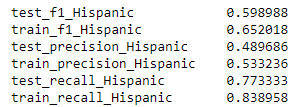

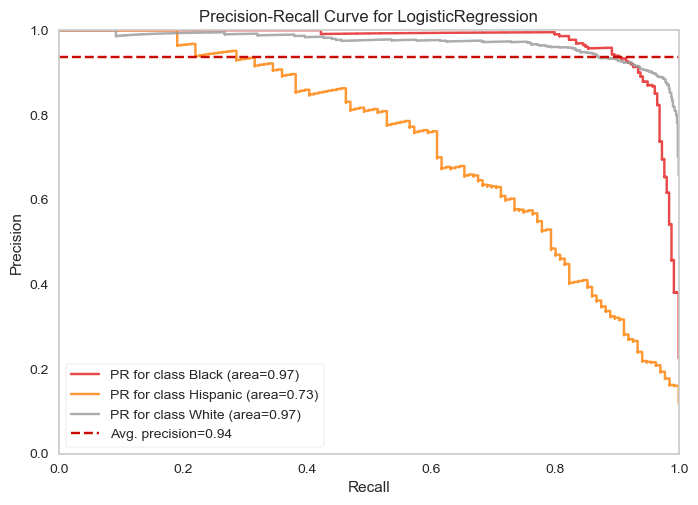

In [55]:
from yellowbrick.classifier import PrecisionRecallCurve

operations = [("OneHotEncoder", column_trans), ("log", LogisticRegression(C=0.8, class_weight='balanced',max_iter=10000,
                                                                          random_state=101))]
model = Pipeline(steps=operations)

viz = PrecisionRecallCurve(
    model,
    per_class=True, classes= ["Black", "Hispanic", "White"],   # Tabloda isimler gorunsun diye bunu yazdik.
    cmap="Set1"
)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show();

# Dengesiz bir dataseti oldugu icin PrecisionRecallCurve' e baktik. 
# Hispanic class' inin skorlari kotu oldugu icin onun skorlarina odaklaniyoruz. 
# Modelin genel performansina gore Hispanic' leri tespit etmedeki genel basari %74

In [56]:
# viz.score_' a bakarak yukaridaki grafikteki skorlari yazdirabiliriz

viz.score_  # Bu skorlari asagida kiyaslayabilmek icin asagida bir degiskene atadik. 

{'Black': 0.9736862029490467,
 'Hispanic': 0.734609867027443,
 'White': 0.9712394250777694,
 'micro': 0.9372854741488735}

In [57]:
viz.score_["Hispanic"]

0.734609867027443

In [58]:
log_AP = viz.score_["Hispanic"]    # log modelden aldigimiz Hispanic classs' ina ait Avg. precision skoru

In [59]:
y_pred = log_model_grid.predict(X_test)

log_AP = viz.score_["Hispanic"] 
log_f1 = f1_score(y_test, y_pred, average=None, labels=["Hispanic"])            # Hispanic f1 skoru
log_recall = recall_score(y_test, y_pred, average=None, labels=["Hispanic"])    # Hispanic recall skoru

# Skorları karşılaştırmak için sadece Hispanic' lere ait test skorlarini degiskenlere atadik
# Multiclass datalarda f1, recall, precision skorlari icin average mutlaka belirtilmeli. 
# Biz sinifin direk kendisini istedigimiz icin, ortalama deger istemedigimiz icin none olarak belirttik.
# Multiclass' larda average belirtilmek zorunda.
# labels=["Hispanic"] -----> Hangi class' in skoru alinacak ise mutlaka koseli parantez icinde yazilmali. 
# Tercihe gore koseli parantez icine virgul konup diger class isimleri de yazilabilirdi. 
# Eger birden fazla class ismi belirtilirse average=macro veya average=weight yazilir ve 
# belirtilen class' larin ortalama degerleri dondurulur. Biz burada tek bir class' a ait skorlara bakacagiz.

# Eğer elimizde dengesiz bir data seti varsa ilk yapacağımız iş müşteriden daha fazla veri talep etmek olmalı !!

## Lojistic Regression solver "liblenear" for small dataset

__liblenear__ kucuk datasetlerinde iyi sonuclar verdigi icin yukaridaki GridSearch isleminde denemistik ama en iyi score' da bunu secmedi. Dikkat edilmesi gereken husus; liblinear sadece __penalty="l1"__ ile calisir, yoksa hata verir.

In [60]:
operations = [("OneHotEncoder", column_trans), ("log", LogisticRegression(class_weight='balanced',max_iter=10000,
                                                                    random_state=101, solver="liblinear", penalty="l1"))]

# liblenear kucuk datasetlerinde iyi sonuclar verdigi icin yukaridaki GridSearch isleminde denemistik ama
# en iyi score' da bunu secmedi. Dikkat edilmesi gereken husus; liblinear sadece penalty="l1" ile calisir, yoksa hata verir.

In [61]:
pipe_log_model_libl = Pipeline(steps=operations)

Kurdugumuz bu modelde Black ve White skorlarinin cok iyilestigini goruyoruz. Hispanic skorlari yukaridaki skora gore dusuk fakat precision, recall ve f1 skorlari birbirleriyle cok dengeli. Musteriye dengeli skorlar olarak bu model sunulabilir. Boyle dengeli bir modelden yeniden bir treshold tespit edilip, dengesiz datasetimiz icin precision ve recall' i birbirine olabildigince yaklastirabiliriz. Biz simdilik bunu tercih etmedik.

In [62]:
pipe_log_model_libl.fit(X_train,y_train)
eval_metric(pipe_log_model_libl, X_train, y_train, X_test, y_test)

# Kurdugumuz bu modelde Black ve White skorlarinin cok iyilestigini goruyoruz. 
# Hispanic skorlari yukaridaki skora gore dusuk fakat precision, recall ve f1 skorlari birbirleriyle cok dengeli. 
# Musteriye dengeli skorlar olarak bu model sunulabilir. 
# Boyle dengeli bir modelden yeniden bir treshold tespit edilip, dengesiz datasetimiz icin 
# precision ve recall' i birbirine olabildigince yaklastirabiliriz. Biz simdilik bunu tercih etmedik.

Test_Set
[[245   4  11]
 [  5  96  35]
 [ 18  34 706]]
              precision    recall  f1-score   support

       Black       0.91      0.94      0.93       260
    Hispanic       0.72      0.71      0.71       136
       White       0.94      0.93      0.94       758

    accuracy                           0.91      1154
   macro avg       0.86      0.86      0.86      1154
weighted avg       0.91      0.91      0.91      1154


Train_Set
[[ 975   19   44]
 [  29  386  128]
 [  43  146 2845]]
              precision    recall  f1-score   support

       Black       0.93      0.94      0.94      1038
    Hispanic       0.70      0.71      0.71       543
       White       0.94      0.94      0.94      3034

    accuracy                           0.91      4615
   macro avg       0.86      0.86      0.86      4615
weighted avg       0.91      0.91      0.91      4615



In [63]:
model = Pipeline(steps=operations)

scores = cross_validate(model, X_train, y_train, scoring = scoring, cv = 10, return_train_score=True)
df_scores = pd.DataFrame(scores, index = range(1, 11))
df_scores.mean()[2:]

# Cross Validate islemi ile Hispanic skorlarimizi teyit ettik. 
# Tek seferlik skorlara gore biraz dusuk ciksa da asagi yukari ayni skorlari elde ettik
# Yukarıda gridsearch sonrası aldığım recall skorları daha iyiydi.
# Burdaki precision ve f1 skorları ise biraz daha yüksek.

test_f1_Hispanic           NaN
train_f1_Hispanic          NaN
test_precision_Hispanic    NaN
train_precision_Hispanic   NaN
test_recall_Hispanic       NaN
train_recall_Hispanic      NaN
dtype: float64

## 2. SVC

### Vanilla SVC model 

In [64]:
operations_svc = [("OneHotEncoder", column_trans), ("svc", SVC(class_weight="balanced",random_state=101))]

pipe_svc_model = Pipeline(steps=operations_svc)

# pipeline' i sifirdan kurmak zorundayiz. Cunku icinde kullanacagimiz model ismi degisti.

In [65]:
pipe_svc_model.fit(X_train, y_train)
eval_metric(pipe_svc_model, X_train, y_train, X_test, y_test)

# SVC skorlarinin asagi yukari Logistic Regression ile yakin skorlar elde ettik.
# Precision degeri yukarida %52 idi, burada %48' e dusmus; f1 skoru yukarida %63 idi burda %60' a dusmus

Test_Set
[[240  12   8]
 [  5 111  20]
 [ 20 109 629]]
              precision    recall  f1-score   support

       Black       0.91      0.92      0.91       260
    Hispanic       0.48      0.82      0.60       136
       White       0.96      0.83      0.89       758

    accuracy                           0.85      1154
   macro avg       0.78      0.86      0.80      1154
weighted avg       0.89      0.85      0.86      1154


Train_Set
[[ 956   42   40]
 [  23  456   64]
 [  54  426 2554]]
              precision    recall  f1-score   support

       Black       0.93      0.92      0.92      1038
    Hispanic       0.49      0.84      0.62       543
       White       0.96      0.84      0.90      3034

    accuracy                           0.86      4615
   macro avg       0.79      0.87      0.81      4615
weighted avg       0.90      0.86      0.87      4615



In [66]:
model = Pipeline(steps=operations_svc)

scores = cross_validate(model, X_train, y_train, scoring = scoring, cv = 10, return_train_score=True)
df_scores = pd.DataFrame(scores, index = range(1, 11))
df_scores.mean()[2:]

# Cross Validate isleminden aldigimiz skorlarin tek seferlik skorlar ile yakin oldugunu soyleyebiliriz 

test_f1_Hispanic           NaN
train_f1_Hispanic          NaN
test_precision_Hispanic    NaN
train_precision_Hispanic   NaN
test_recall_Hispanic       NaN
train_recall_Hispanic      NaN
dtype: float64

###  SVC Model GridsearchCV

In [67]:
param_grid = {
    'svc__C': [0.5, 1],
    'svc__gamma': ["scale", "auto", 0.01]    # Makine gucunden dolayi cok genis tutmadik
}

In [68]:
operations_svc = [("OneHotEncoder", column_trans), ("svc", SVC(class_weight="balanced",random_state=101))]

# GridSearch veya Cross Validate oncesi modeli sifirlamak onemli

In [69]:
model = Pipeline(steps=operations_svc)

In [70]:
svm_model_grid = GridSearchCV(model,
                              param_grid,
                              verbose=3,
                              scoring=recall_Hispanic,
                              cv=10,
                              n_jobs=-1,
                              return_train_score=True)

# yine sadece recall_hispanic skorlarini tanimladik. Cunku onu yukseltecek best parametreleri ariyoruz

In [71]:
svm_model_grid.fit(X_train, y_train)

Fitting 10 folds for each of 6 candidates, totalling 60 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('OneHotEncoder',
                                        ColumnTransformer(remainder=MinMaxScaler(),
                                                          transformers=[('onehotencoder',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                                       ('svc',
                                        SVC(class_weight='balanced',
                                            random_state=101))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.5, 1],
                         'svc__gamma': ['scale', 'auto', 0.01]},
             return_train_score=True,
             scoring=make_scorer(recall_score, response_method='predict', average=None, labels=['Hispanic']),
             verbose=3)

In [72]:
svm_model_grid.best_params_

#Grid Search best_parametre degerlerini defalult değerlerde bırakmış

{'svc__C': 0.5, 'svc__gamma': 'scale'}

In [73]:
svm_model_grid.best_score_

# Grid Search best_score' u 0.76 olarak buldu. Yukarida Cross Validate ile elde ettigimiz skora yakin bir skor cikti

nan

In [74]:
eval_metric(svm_model_grid, X_train, y_train, X_test, y_test)

# Grid Search islemi sonrasi Hispanic class' ina ait precision degerinin biraz daha arttigini, 
# diger skorlarin pek degismedigini goruyoruz. Logistic model skorlarina yaklastik sayılır

Test_Set
[[239  10  11]
 [  5 109  22]
 [ 18 114 626]]
              precision    recall  f1-score   support

       Black       0.91      0.92      0.92       260
    Hispanic       0.47      0.80      0.59       136
       White       0.95      0.83      0.88       758

    accuracy                           0.84      1154
   macro avg       0.78      0.85      0.80      1154
weighted avg       0.88      0.84      0.86      1154


Train_Set
[[ 944   44   50]
 [  30  432   81]
 [  50  456 2528]]
              precision    recall  f1-score   support

       Black       0.92      0.91      0.92      1038
    Hispanic       0.46      0.80      0.59       543
       White       0.95      0.83      0.89      3034

    accuracy                           0.85      4615
   macro avg       0.78      0.85      0.80      4615
weighted avg       0.89      0.85      0.86      4615



In [75]:
operations_svc = [("OneHotEncoder", column_trans), ("svc", SVC(C=0.5, gamma='scale', class_weight="balanced",random_state=101))]

# PrecisionRecall oncesi modelimizi sifirladik.

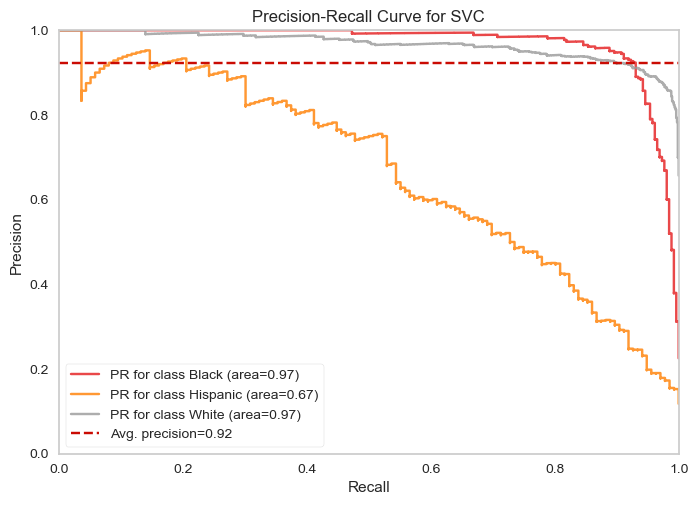

In [76]:
model = Pipeline(steps=operations_svc)

viz = PrecisionRecallCurve(
    model,
    per_class=True, classes= ["Black", "Hispanic", "White"],
    cmap="Set1"
)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show();

# Logistic modelde PrecisionRecall' da Hispanic class' inin genel performansi %74 idi burda %72' ye dustu

In [77]:
y_pred = svm_model_grid.predict(X_test)

svc_AP = viz.score_["Hispanic"]
svc_f1 = f1_score(y_test, y_pred, average=None, labels=["Hispanic"])
svc_recall = recall_score(y_test, y_pred, average=None, labels=["Hispanic"])

# Tum model sonuclarini asagida karsilastirmak icin cikan skorlarimizi tekrar degiskenlere atadik

## 3. RF

**Ensemble modellerde ordinal encoder kullanılmasının skorları ve hızı iyileştirdiğine dair çeşitli çalışmalar mevcut**

In [78]:
cat

Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object')

**handle_unknown='use_encoded_value', unknown_value=-1** parametreleri, modelin daha önce görmediği (yani eğitim veri setinde olmayan) kategorik değerlerle nasıl başa çıkacağını belirtir.

- handle_unknown='use_encoded_value': Eğitim sırasında görülmeyen yeni bir kategori değeriyle karşılaşıldığında, bu değeri belirtilen unknown_value ile kodlar.
  
- unknown_value=-1: Eğitim sırasında görülmeyen kategoriler için kullanılacak kodlanmış değer -1'dir.

Bu şekilde, eğitim veri setinde olmayan yeni kategorik değerlerle model karşılaştığında, bu değerler -1 olarak kodlanır. Bu, özellikle modeli gerçek dünya verileriyle test ettiğinizde veya uyguladığınızda yararlı olabilir, çünkü bu tür veriler genellikle eğitim veri setinde olmayan yeni kategoriler içerebilir.

In [79]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

1. **ord_enc, cat**: ord_enc adlı OrdinalEncoder nesnesini, cat adlı sütun veya sütun listesine uygular. Yani, cat sütunlarındaki kategorik değerler, ord_enc ile sayısal değerlere dönüştürülür.

2. **remainder='passthrough'**: Bu argüman, cat dışındaki diğer tüm sütunların (yani işlenmemiş olanların) olduğu gibi bırakılacağını belirtir. Yani, bu sütunlar üzerinde herhangi bir dönüşüm yapılmaz. Bundan sonraki modellerimiz için scaling işlemi gerekli olmadığından passthrough olarak bıraktık.

In [80]:
column_trans = make_column_transformer((ord_enc, cat), remainder='passthrough')  

### Vanilla RF Model

In [81]:
operations_rf = [("OrdinalEncoder", column_trans), ("RF_model", RandomForestClassifier(class_weight="balanced", 
                                                                                    random_state=101))]

In [82]:
pipe_model_rf = Pipeline(steps=operations_rf)

In [83]:
pipe_model_rf.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('RF_model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=101))])

In [84]:
eval_metric(pipe_model_rf, X_train, y_train, X_test, y_test)

# Balance yapmis olmamiza ragmen Hispanic class' inin test setine ait recall ve f1 skorlari cok kotu cikti. 
# Train setindeki skorlar %100, Test seti skorlari cok kotu. Overfitting durumu var. 
# Sonraki adimlarda hyperparametreler ile oynayarak skorlari iyilestirmeye calisacagiz

Test_Set
[[191   0  69]
 [ 10   6 120]
 [ 10   2 746]]
              precision    recall  f1-score   support

       Black       0.91      0.73      0.81       260
    Hispanic       0.75      0.04      0.08       136
       White       0.80      0.98      0.88       758

    accuracy                           0.82      1154
   macro avg       0.82      0.59      0.59      1154
weighted avg       0.82      0.82      0.77      1154


Train_Set
[[1038    0    0]
 [   0  542    1]
 [   0    0 3034]]
              precision    recall  f1-score   support

       Black       1.00      1.00      1.00      1038
    Hispanic       1.00      1.00      1.00       543
       White       1.00      1.00      1.00      3034

    accuracy                           1.00      4615
   macro avg       1.00      1.00      1.00      4615
weighted avg       1.00      1.00      1.00      4615



In [85]:
operations_rf = [("OrdinalEncoder", column_trans), ("RF_model", RandomForestClassifier(class_weight="balanced", 
                                                                                    random_state=101))]

model = Pipeline(steps=operations_rf)

scores = cross_validate(model, X_train, y_train, scoring = scoring, cv = 5, return_train_score=True)
df_scores = pd.DataFrame(scores, index = range(1, 6))
df_scores.mean()[2:]

# Cross Validate islemi sonrasinda aldigimiz skorlarin tek seferlik skorlar ile benzer oldugunu goruyoruz

test_f1_Hispanic           NaN
train_f1_Hispanic          NaN
test_precision_Hispanic    NaN
train_precision_Hispanic   NaN
test_recall_Hispanic       NaN
train_recall_Hispanic      NaN
dtype: float64

### RF Model GridsearchCV

In [86]:
param_grid = {
    'RF_model__n_estimators': [100, 200, 400],
    'RF_model__max_depth': [2, 3, 4],
    'RF_model__min_samples_split': [18, 20],
    'RF_model__max_features': ['sqrt', None, 15]  
}

In [87]:
operations_rf = [("OrdinalEncoder", column_trans),
                 ("RF_model", RandomForestClassifier(class_weight="balanced", random_state=101))]

model = Pipeline(steps=operations_rf)

rf_grid_model = GridSearchCV(model,
                             param_grid,
                             verbose=3,
                             scoring=recall_Hispanic,  
                             n_jobs=-1,
                             return_train_score=True)

In [88]:
rf_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(estimator=Pipeline(steps=[('OrdinalEncoder',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinalencoder',
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                                       ('RF_model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=101))]),
             n_jobs=-1,
             param_grid={'RF_model__max_depth': [2, 3, 4],
                         'RF_model__max_features': ['sqrt', None, 15],
                         'RF_model__min_samples_split': [18, 20],
                         'RF_model__n_estimators': [100, 200, 400]},
             return_train_score=True,
             scoring=make_scorer(recall_score, response_method='predict', average=None, labels=['Hispanic']),
             verbose=3)

In [89]:
rf_grid_model.best_params_

{'RF_model__max_depth': 2,
 'RF_model__max_features': 'sqrt',
 'RF_model__min_samples_split': 18,
 'RF_model__n_estimators': 100}

In [90]:
eval_metric(rf_grid_model, X_train, y_train, X_test, y_test)

# Model, overfitting' i engellerken oncelikle test seti skorlarini train setine dogru cekmeye calisir; 
# basaramazsa train seti skorlari test seti skorlarina yaklasir. 
# Su anda Random Forest modele ne yaparsak yapalim skorlar cok fazla duzelmeyecek

Test_Set
[[167  48  45]
 [ 16  72  48]
 [ 98 236 424]]
              precision    recall  f1-score   support

       Black       0.59      0.64      0.62       260
    Hispanic       0.20      0.53      0.29       136
       White       0.82      0.56      0.67       758

    accuracy                           0.57      1154
   macro avg       0.54      0.58      0.53      1154
weighted avg       0.70      0.57      0.61      1154


Train_Set
[[ 684  187  167]
 [  57  333  153]
 [ 255 1096 1683]]
              precision    recall  f1-score   support

       Black       0.69      0.66      0.67      1038
    Hispanic       0.21      0.61      0.31       543
       White       0.84      0.55      0.67      3034

    accuracy                           0.59      4615
   macro avg       0.58      0.61      0.55      4615
weighted avg       0.73      0.59      0.63      4615



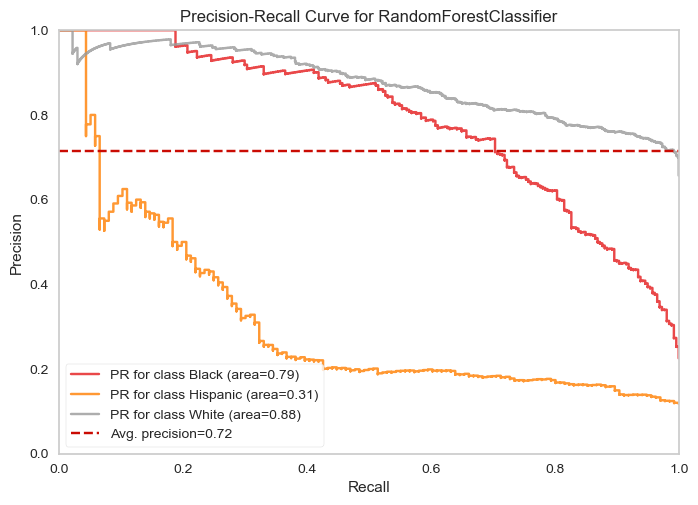

In [91]:
operations_rf = [("OrdinalEncoder", column_trans), ("RF_model", RandomForestClassifier(class_weight="balanced", 
                                                    max_depth=2, n_estimators=100, max_features='sqrt', 
                                                    min_samples_split=18, random_state=101))]

model = Pipeline(steps=operations_rf)

viz = PrecisionRecallCurve(
    model,
    per_class=True, classes= ["Black", "Hispanic", "White"],
    cmap="Set1"
)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show();

# Hispanic class' ina ait genel performans skoru %33 cikti. Genel performans cok kotu.

In [92]:
y_pred = rf_grid_model.predict(X_test)

rf_AP = viz.score_["Hispanic"]
rf_f1 = f1_score(y_test, y_pred, average=None, labels=["Hispanic"])
rf_recall = recall_score(y_test, y_pred, average=None, labels=["Hispanic"])

## 4. XGBoost

### Vanilla XGBoost Model

In [93]:
# conda install -c conda-forge xgboost
# !pip install xgboost==0.90

In [94]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Define the pipeline
operations_xgb = [("OrdinalEncoder", column_trans), ("XGB_model", XGBClassifier(random_state=101))]

pipe_model_xgb = Pipeline(steps=operations_xgb)

# Fit the pipeline with the encoded target labels
pipe_model_xgb.fit(X_train, y_train_encoded)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('XGB_model',
                 XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
                               colsample_bylevel=1...
                               gamma=0, gpu_id=-1, grow_policy='depthwise',
                               importance_type=None, interaction_constraints='',
                               learning_rate=0.300000012, max_bin=256,
                               max_cat_to_onehot=4, max_delta_step=0,
                               max_depth=6, max_leaves=0, min_child_weight=1,
                               missing=nan, monotone_constraints='()',
                               n_estimators=100, n_jobs=0, num_parallel_tree=1,
                               objective='multi:softprob', predictor='auto',
                               random_state=101, reg_alpha=0, ...))])

**class_weight.compute_sample_weight** fonksiyonu, scikit-learn kütüphanesinin bir parçasıdır ve sınıf ağırlıklarını hesaplamak için kullanılır. Bu özellikle dengesiz veri setleri için yararlıdır, yani bir sınıfın örnek sayısı diğer sınıflardan çok daha fazla veya az olduğunda.

**class_weight='balanced'** parametresi, her bir sınıf için ağırlıkların "dengelenmiş" olmasını sağlar. Bu, her sınıfın örnek sayısının tersi ile orantılı ağırlıklar oluşturur. Matematiksel olarak, bir sınıfın ağırlığı şu şekilde hesaplanır:

**Ağırlık (sınıf i) = Toplam Örnek Sayısı / (Sınıf Sayısı x Sınıf i'nin Örnek Sayısı)**

Bu hesaplanan ağırlıklar, **classes_weights** değişkeninde saklanır ve bu ağırlıklar, model eğitimi sırasında kullanılabilir. Örneğin, bu ağırlıklar bir sınıflandırma modelinin **fit** fonksiyonuna **sample_weight** parametresi olarak verilebilir:


Bu yaklaşım, modelin dengesiz sınıf dağılımını dikkate almasını ve azınlık sınıfına daha fazla önem vermesini sağlar. Bu, modelin genel performansını iyileştirebilir, özellikle azınlık sınıfının doğru bir şekilde sınıflandırılması önemliyse.

Eger modelde unbalance datalari dengeli hale getirecek bir hyperparametre yok ise class_weight fonksiyonu kullanilarak datadaki dengesiz veriler dengelenebilir. 

Asinda modelin icinde unbalance datalarda balance saglamak icin kullanilan __scale_pos_weight__ parametresi var ama bu sadece 2 class oldugu zaman ise yarar. Burada 2' den fazla class var, bu yuzden kullanamiyoruz

In [95]:
from sklearn.utils import class_weight
classes_weights = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)
classes_weights

array([2.8330264 , 0.50703142, 0.50703142, ..., 0.50703142, 1.4820167 ,
       0.50703142])

In [96]:
comp = pd.DataFrame(classes_weights, columns=["weights"], index = y_train.index)

comp["label"] = y_train
comp.head()

,weights,label
893,2.833026,Hispanic
196,0.507031,White
3821,0.507031,White
3206,0.507031,White
4500,1.482017,Black


label' a gore groupby yaptigimizda her class icin agirlik katsayilarini verdi. Yani class' lardaki degerleri bu sayilarla carpacak. En fazla agirligi Hispanic class' ina vermis cunku en az sample sayisi ona ait. (1038 Black, 543 Hispanic, 3034 White sample var)

In [97]:
comp.groupby("label")["weights"].value_counts()

# label' a gore groupby yaptigimizda her class icin agirlik katsayilarini verdi. 
# Yani class' lardaki degerleri bu sayilarla carpacak. 
# En fazla agirligi Hispanic class' ina vermis cunku en az sample sayisi ona ait.

label     weights 
Black     1.482017    1038
Hispanic  2.833026     543
White     0.507031    3034
Name: count, dtype: int64

In [98]:
pipe_model_xgb.fit(X_train,y_train_encoded, XGB_model__sample_weight=classes_weights)

# classes_weights degiskenini fit asamasinda yazdigimizda, agirliklandirma islemini burada yapmis oluruz :
# XGBoost'taki ağırlık parametresi sınıf başına değil, örnek başınadır. 
# Bu nedenle her sınıfın ağırlığını örneklerine atamamız gerekir ki bu da aynı şeydir.

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('XGB_model',
                 XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
                               colsample_bylevel=1...
                               gamma=0, gpu_id=-1, grow_policy='depthwise',
                               importance_type=None, interaction_constraints='',
                               learning_rate=0.300000012, max_bin=256,
                               max_cat_to_onehot=4, max_delta_step=0,
                               max_depth=6, max_leaves=0, min_child_weight=1,
                               missing=nan, monotone_constraints='()',
                               n_estimators=100, n_jobs=0, num_parallel_tree=1,
                               objective='multi:softprob', predictor='auto',
                               random_state=101, reg_alpha=0, ...))])

In [99]:
# Encode y_test using the same LabelEncoder
y_test_encoded = label_encoder.transform(y_test)

# Now you can pass the encoded y_test to your eval_metric function
eval_metric(pipe_model_xgb, X_train, y_train_encoded, X_test, y_test_encoded)

Test_Set
[[231   2  27]
 [ 11  64  61]
 [ 21  20 717]]
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       260
           1       0.74      0.47      0.58       136
           2       0.89      0.95      0.92       758

    accuracy                           0.88      1154
   macro avg       0.84      0.77      0.79      1154
weighted avg       0.87      0.88      0.87      1154


Train_Set
[[1038    0    0]
 [   0  543    0]
 [   0    0 3034]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1038
           1       1.00      1.00      1.00       543
           2       1.00      1.00      1.00      3034

    accuracy                           1.00      4615
   macro avg       1.00      1.00      1.00      4615
weighted avg       1.00      1.00      1.00      4615



In [100]:
operations_xgb = [("OrdinalEncoder", column_trans), ("XGB_model", XGBClassifier(random_state=101))]

model = Pipeline(steps=operations_xgb)

scores = cross_validate(model, X_train, y_train_encoded, scoring = scoring, cv = 5, return_train_score=True,
                        fit_params={"XGB_model__sample_weight":classes_weights})
df_scores = pd.DataFrame(scores, index = range(1, 6))
df_scores.mean()[2:]

# Cross Validate sonucu aldigimiz skorlar yukaridaki tek seferlik skorlar ile benzer
# Eger ki class_weight ile datalari dengeli hale getirmeseydik cok daha kotu sonuclar alacaktik. 
# Bu islemden sonra bile skorlarimizin cok iyi olmadigini goruyoruz. 
# Hispanic class'inin Train ve Test set skorlari arasinda cok fark var; yani overfitting bir durum var. 
# Asagida bu skorlari GridSearch isleminde hyperparametreler ile oynayarak skorlari duzeltmeye calisacagiz

test_f1_Hispanic            0.0
train_f1_Hispanic           0.0
test_precision_Hispanic     0.0
train_precision_Hispanic    0.0
test_recall_Hispanic        0.0
train_recall_Hispanic       0.0
dtype: float64

### XGBoost Model GridsearchCV

In [101]:
param_grid = {"XGB_model__n_estimators":[10, 20, 40],
              'XGB_model__max_depth':[2,3,4],
              "XGB_model__learning_rate": [0.03, 0.05, 0.1],
              "XGB_model__subsample":[0.5, 0.8, 1],
              "XGB_model__colsample_bytree":[0.8, 1]}

In [102]:
operations_xgb = [("OrdinalEncoder", column_trans), ("XGB_model", XGBClassifier(random_state=101))]

model = Pipeline(steps=operations_xgb)

xgb_grid_model = GridSearchCV(model, 
                              param_grid, 
                              scoring=recall_Hispanic,
                              cv=5,
                              n_jobs = -1,
                              return_train_score=True)

# GridSearch isleminde yine sadece Hispanic class' ina ait skorlari hesapliyoruz

In [103]:
xgb_grid_model.fit(X_train, y_train_encoded, XGB_model__sample_weight=classes_weights)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('OrdinalEncoder',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinalencoder',
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                                       ('XGB_model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks...
                                                      reg_alpha=None,
                                                      reg_lambda=None, ...))]),
             n_jobs=-1,
             param_grid={'XGB_model__colsample_bytree': [0.8, 1],
                         'XGB_model__learning_rate': [0.03, 0.05, 0.1],
                         'XGB_model__max_depth': [2, 3, 4],
                         'XGB_model__n_estimators': [10, 20, 40],
                         'XGB_model__subsample': [0.5, 0.8, 1]},
             return_train_score=True,
             scoring=make_scorer(recall_score, response_method='predict', average=None, labels=['Hispanic']))

In [104]:
xgb_grid_model.best_params_   

{'XGB_model__colsample_bytree': 0.8,
 'XGB_model__learning_rate': 0.03,
 'XGB_model__max_depth': 2,
 'XGB_model__n_estimators': 10,
 'XGB_model__subsample': 0.5}

In [105]:
eval_metric(xgb_grid_model, X_train, y_train_encoded, X_test, y_test_encoded)

# Overfitting gidermek adına skorlar düşmüş ama bu şekilde de skorlar çok kötü gelmiş, model underfitting denilebilir.

Test_Set
[[186  45  29]
 [ 18  74  44]
 [103 208 447]]
              precision    recall  f1-score   support

           0       0.61      0.72      0.66       260
           1       0.23      0.54      0.32       136
           2       0.86      0.59      0.70       758

    accuracy                           0.61      1154
   macro avg       0.56      0.62      0.56      1154
weighted avg       0.73      0.61      0.64      1154


Train_Set
[[ 717  191  130]
 [  74  328  141]
 [ 287  834 1913]]
              precision    recall  f1-score   support

           0       0.67      0.69      0.68      1038
           1       0.24      0.60      0.35       543
           2       0.88      0.63      0.73      3034

    accuracy                           0.64      4615
   macro avg       0.59      0.64      0.59      4615
weighted avg       0.75      0.64      0.68      4615



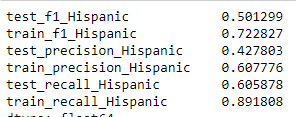

XGBoost ve Random Forest' in bu datasetinde cok kotu skorlar verdigini soyleyebiliriz.

XGBoost modelin, Hispanic class' ina ait recall degerini tahmin etmedeki genel performansi %58 : 

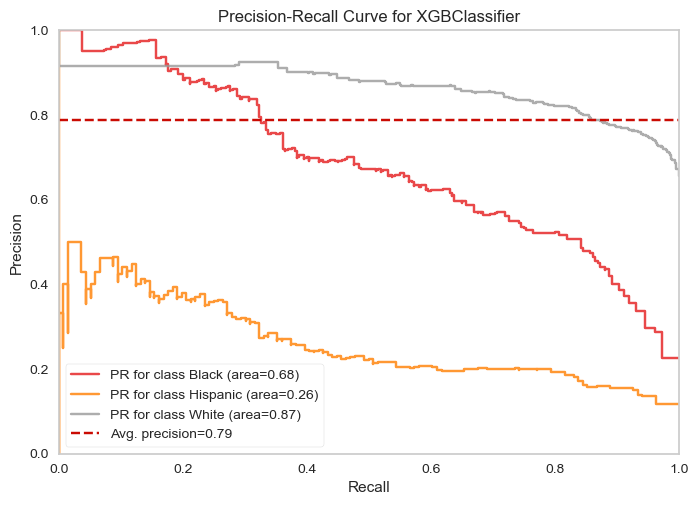

In [106]:
from yellowbrick.classifier import PrecisionRecallCurve

operations_xgb = [("OrdinalEncoder", column_trans), 
                  ("XGB_model", XGBClassifier(colsample_bytree=0.8, 
                                              learning_rate=0.03, 
                                              max_depth=2, 
                                              n_estimators=10, 
                                              random_state=101, 
                                              subsample=0.5))]

model = Pipeline(steps=operations_xgb)

viz = PrecisionRecallCurve(
    model,
    per_class=True,
    classes=["Black", "Hispanic", "White"],
    cmap="Set1",
    sample_weight=classes_weights
)
viz.fit(X_train, y_train_encoded)
viz.score(X_test, y_test_encoded)
viz.show();

In [107]:
y_pred = xgb_grid_model.predict(X_test)

xgb_AP = viz.score_["Hispanic"]
xgb_f1 = f1_score(y_test_encoded, y_pred, average=None, labels=["Hispanic"])
xgb_recall = recall_score(y_test_encoded, y_pred, average=None, labels=["Hispanic"])

## Comparing Models

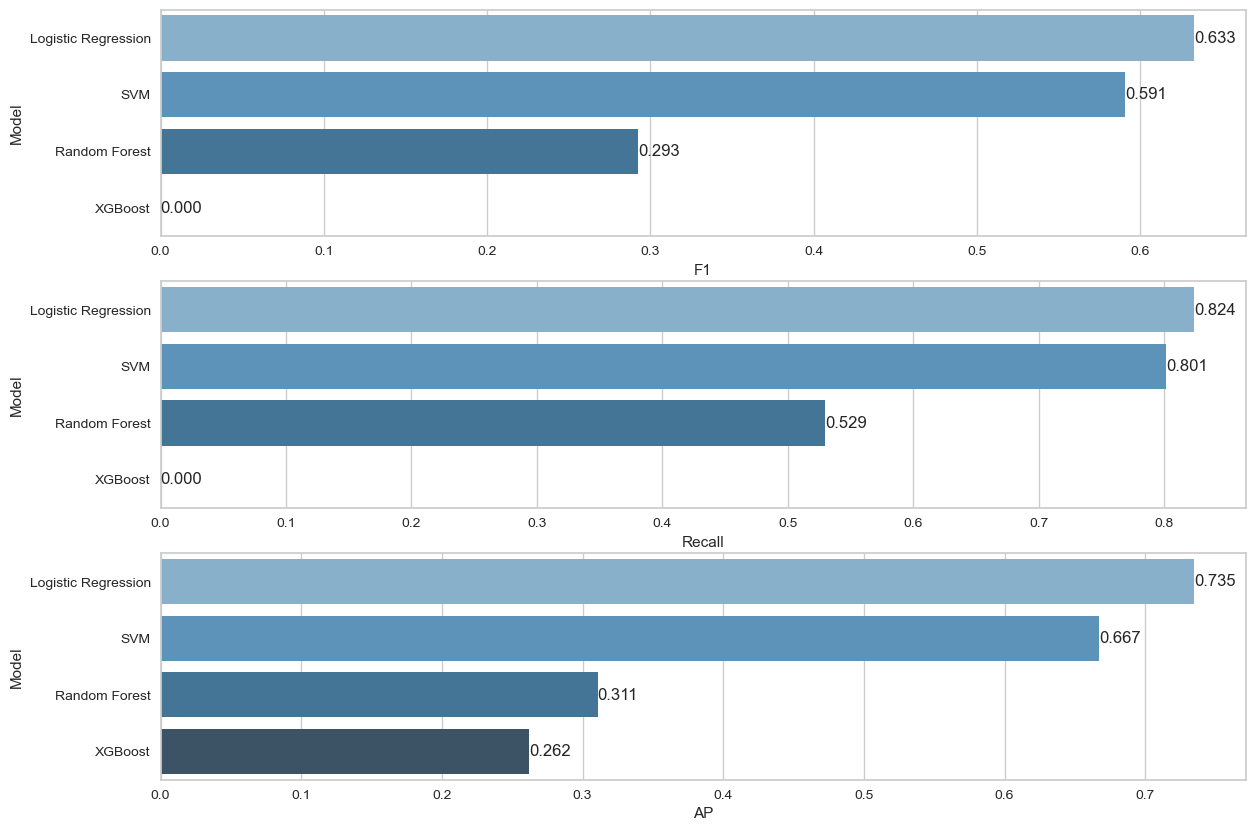

In [108]:
compare = pd.DataFrame({"Model": ["Logistic Regression", "SVM",  "Random Forest", "XGBoost"],
                        "F1": [log_f1[0], svc_f1[0], rf_f1[0], xgb_f1[0]],
                        "Recall": [log_recall[0], svc_recall[0], rf_recall[0], xgb_recall[0]],
                        "AP": [log_AP, svc_AP, rf_AP, xgb_AP]})    # Dengesiz datasetlerinde modelin genel performansi.

def labels(ax):   # Sayilari yazdirmak icin.
    for p in ax.patches:
        width = p.get_width()                        # get bar length
        ax.text(width,                               # set the text at 1 unit right of the bar
                p.get_y() + p.get_height() / 2,      # get Y coordinate + X coordinate / 2
                '{:1.3f}'.format(width),             # set variable to display, 2 decimals
                ha = 'left',                         # horizontal alignment
                va = 'center')                       # vertical alignment
    
plt.figure(figsize=(14,10))
plt.subplot(311)
compare = compare.sort_values(by="F1", ascending=False)
ax=sns.barplot(x="F1", y="Model", data=compare, palette="Blues_d")        # f1 score
labels(ax)

plt.subplot(312)
compare = compare.sort_values(by="Recall", ascending=False)
ax=sns.barplot(x="Recall", y="Model", data=compare, palette="Blues_d")   # recall score
labels(ax)

plt.subplot(313)
compare = compare.sort_values(by="AP", ascending=False)
ax=sns.barplot(x="AP", y="Model", data=compare, palette="Blues_d")       # average precision score
labels(ax)
plt.show()

- Recall score Logistic ve SVM'de aynı. 
- Genel performans ve F1 skorlarinin az da olsa Logistik modelde yüksek oldugunu goruyoruz.
- Bu yuzden Logistic Modeli secmek mantikli olur. 
- Skorlar ayni olsa bile SVM modeli secmek mantikli olmaz. Cunku bu modelde calisma maliyeti yuksek ve feature importance yapamiyoruz. 
- Logistic Regression'da feature importance yapabiliriz (Ridge-Lasso).

# Before the Deployment 
- Choose the model that works best based on your chosen metric
- For final step, fit the best model with whole dataset to get better performance.
- And your model ready to deploy, dump your model and scaler.

In [109]:
# Final model icin pipeline' i yeniden tanimlayarak modelimizi egitiyoruz

column_trans_final = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat), 
                                       remainder=MinMaxScaler())

operations_final = [("OneHotEncoder",column_trans_final),("log", LogisticRegression(C=0.8, class_weight='balanced',max_iter=10000,
                                                                          random_state=101))]

final_model = Pipeline(steps=operations_final)

In [110]:
final_model.fit(X, y)

Pipeline(steps=[('OneHotEncoder',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('log',
                 LogisticRegression(C=0.8, class_weight='balanced',
                                    max_iter=10000, random_state=101))])

In [111]:
# Veri setimdeki "male" olan gözlemlerin mean degerlerini alip bir insana aitmis gibi 
# modele prediction yapmasi amaciyla vereceğim

X.describe()

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Age
count,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.00000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000,5769.000000
mean,247.254290,1408.630265,328.071590,225.201768,1301.902583,244.408043,195.118911,399.706015,341.663027,274.903449,491.454845,72.335413,324.962212,306.677760,139.529381,1022.059456,242.234356,872.112845,610.449991,498.331773,386.316519,1479.952158,283.232623,1024.206622,252.322586,1254.290172,827.105738,622.693708,351.880222,35.175420,62.606171,22.227249,240.553302,786.399203,98.915063,263.512394,339.458832,295.661640,553.098284,467.898769,1104.347201,85.098111,204.215635,189.574796,152.043682,570.424337,196.640839,333.274918,70.834113,348.930837,386.417923,1042.152366,632.534928,412.773964,433.017334,476.665280,541.376668,484.316693,69.76183,406.943144,119.601664,376.127578,414.554516,1390.525048,114.106604,417.227076,259.757670,1131.214422,354.805166,145.202288,898.592477,868.361068,578.013001,1766.951118,1716.938984,1405.392442,1101.631479,623.583637,176.696481,791.044548,459.389149,129.580343,884.659386,1632.470966,460.990293,318.409950,916.817126,230.459178,377.352054,1033.591090,800.981106,169.308372,831.334547,29.776391
std,37.457748,78.303123,20.444554,15.965783,71.260913,16.803556,13.379000,30.124094,41.270615,19.239580,42.011888,5.326965,17.050426,20.818789,7.248670,75.952953,26.4

In [112]:
X[X.Gender=="Male"].describe()

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Age
count,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.00000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000,3899.000000
mean,255.449090,1442.946397,335.819441,229.590921,1331.098487,252.16594,201.229546,416.004360,358.579636,275.632213,510.927674,74.844063,331.655809,315.718389,142.434983,1021.294178,246.362401,889.500385,619.217235,504.001026,392.426520,1519.422160,289.786868,1060.496794,254.390100,1293.040267,847.637599,623.143114,356.354706,36.095153,64.171070,23.109772,244.823544,804.885099,101.893819,271.573993,349.573480,310.528084,580.702231,480.928956,1132.125673,88.379841,212.571172,193.509361,154.183637,574.708130,199.760708,344.002052,72.564504,346.256732,379.948448,1063.412670,639.948705,431.393947,450.628623,489.366504,555.224929,492.625545,73.061554,409.670685,122.684534,398.192101,435.159528,1428.469351,116.610156,430.684791,268.313927,1179.902539,364.305976,149.832265,918.678636,897.179277,594.007951,1816.628879,1758.385483,1440.699667,1122.444473,626.335214,180.739420,813.085407,469.222878,131.116697,902.586817,1666.783278,478.017953,327.110798,943.043344,238.560400,388.017440,1058.239805,858.714286,176.168761,848.762247,30.172352
std,37.295117,62.356906,17.281413,14.579399,58.714251,12.89351,10.329358,19.074837,34.511924,17.512428,32.450260,4.097052,13.970798,16.640502,6.141613,76.330564,26.4

In [113]:
male_mean_human = X[X.Gender=="Male"].describe(include="all").loc["mean"]
male_mean_human

abdominalextensiondepthsitting      255.44909
acromialheight                    1442.946397
acromionradialelength              335.819441
anklecircumference                 229.590921
axillaheight                      1331.098487
balloffootcircumference             252.16594
balloffootlength                   201.229546
biacromialbreadth                   416.00436
bicepscircumferenceflexed          358.579636
bicristalbreadth                   275.632213
bideltoidbreadth                   510.927674
bimalleolarbreadth                  74.844063
bitragionchinarc                   331.655809
bitragionsubmandibulararc          315.718389
bizygomaticbreadth                 142.434983
buttockcircumference              1021.294178
buttockdepth                       246.362401
buttockheight                      889.500385
buttockkneelength                  619.217235
buttockpopliteallength             504.001026
calfcircumference                   392.42652
cervicaleheight                   

In [114]:
# sayısal sütunların ortalamasını verdik, kategorik sütunlar için rastgele değerler veriyorum

male_mean_human["Gender"] = "Male"
male_mean_human["SubjectsBirthLocation"] = "California"
male_mean_human["WritingPreference"] = "Right hand"

In [115]:
pd.DataFrame(male_mean_human).T

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Gender,SubjectsBirthLocation,Age,WritingPreference
mean,255.44909,1442.946397,335.819441,229.590921,1331.098487,252.16594,201.229546,416.00436,358.579636,275.632213,510.927674,74.844063,331.655809,315.718389,142.434983,1021.294178,246.362401,889.500385,619.217235,504.001026,392.42652,1519.42216,289.786868,1060.496794,254.3901,1293.040267,847.637599,623.143114,356.354706,36.095153,64.17107,23.109772,244.823544,804.885099,101.893819,271.573993,349.57348,310.528084,580.702231,480.928956,1132.125673,88.379841,212.571172,193.509361,154.183637,574.70813,199.760708,344.002052,72.564504,346.256732,379.948448,1063.41267,639.948705,431.393947,450.628623,489.366504,555.224929,492.625545,73.061554,409.670685,122.684534,398.192101,435.159528,1428.469351,116.610156,430.684791,268.313927,1179.902539,364.305976,149.832265,918.678636,897.179277,594.007951,1816.628879,1758.385483,1440.699667,1122.444473,626.335214,180.73942,813.085407,469.222878,131.116697,902.586817,1666.783278,478.017953,327.110798,943.043344,238.5604,388.01744,1058.239805,858.714286,176.168761,848.762247,Male,California,30.172352,Right hand


In [116]:
final_model.predict(pd.DataFrame(male_mean_human).T)

array(['Hispanic'], dtype=object)

In [117]:
# 346. satirdaki gozlemi modelin tahmin etmesini istedik, Hispanic olarak tahmin etti

final_model.predict(X.loc[[346]])

array(['Hispanic'], dtype=object)

In [118]:
# Asagida 346. satirdaki gozlemin gercek degerine baktik, o da Hispanic cikti. Yani modelimiz dogru tahmin yapti

y[346]

'Hispanic'

**Matthews Korelasyon Katsayısı (Matthews Correlation Coefficient - MCC)**

**Nedir?**
Matthews Korelasyon Katsayısı (MCC), sınıflandırma problemleri için bir performans ölçüsüdür. MCC, -1 ile +1 arasında değerler alır. +1 mükemmel bir tahmin, 0 rastgele tahmin ve -1 tam tersi bir tahmin anlamına gelir.

**Ne Amaçla Kullanılır?**
MCC, sınıflandırma modelinin performansını ölçmek için kullanılır, özellikle de dengesiz veri setlerinde.

**Ne Zaman ve Hangi Durumlarda Kullanılır?**
- Dengesiz veri setlerinde
- Farklı sınıfların önemi eşit olduğunda

**Unbalanced Data Setlerinde Önemi**
Dengesiz veri setlerinde, MCC genellikle daha güvenilir bir performans ölçüsüdür çünkü tüm dört olasılığı (TP, TN, FP, FN) dikkate alır.

**Diğer Evaluation Metric'lerden Farkı**
Precision, Recall gibi metrikler genellikle pozitif sınıfı odak alır. MCC ise hem pozitif hem de negatif sınıfların performansını bir arada değerlendirir.

---

**Cohen's Kappa Score**

**Nedir?**
Cohen's Kappa, iki derecelendirici arasındaki anlaşmayı ölçen bir istatistiktir. Sınıflandırma problemleri için de kullanılır ve -1 ile +1 arasında değerler alır.

**Ne Amaçla Kullanılır?**
- Sınıflandırma modelinin performansını değerlendirmek

**Ne Zaman ve Hangi Durumlarda Kullanılır?**
- İki farklı modelin veya derecelendiricinin tahminlerini karşılaştırmak istendiğinde
- Çoklu sınıf problemlerinde
- Dengesiz veri setlerinde

**Unbalanced Data Setlerinde Önemi**
Cohen's Kappa, dengesiz veri setlerinde de kullanılabilir çünkü rastgele tahminlerin etkisini dikkate alır.

**Diğer Evaluation Metric'lerden Farkı**
Cohen's Kappa, rastgele tahminlerin etkisini ortadan kaldırır ve bu yüzden dengesiz veri setlerinde veya farklı sınıf dağılımlarında daha güvenilir bir performans ölçüsüdür.

---

**Kısaca:**

__matthews_corrcoef__ ------> Aldigimiz gercek degerler ile tahmin edilen degerler arasindaki correlation. 

__matthews_corrcoef__ ve __cohen_kappa_score__ ------> eval_metric' de skorlarimizi aldigimizda, accuracy, makro, weighted ve class' larin kendilerine ozel skorlarinin hepsnin birbirinden farkli oldugunu gormustuk. Bunlarin hepsinin skorlarina binaen genel bir skor almamizi saglayan metriklerdir. Dengesiz veri setlerinde kullanilirlar. 

**Not:** Hem Matthews Korelasyon Katsayısı hem de Cohen's Kappa, çoklu sınıf (multiclass) sınıflandırma problemleri için de genelleştirilebilir, ancak en sık ikili sınıflandırma problemlerinde kullanılırlar.

**Bilgi için:** https://towardsdatascience.com/comprehensive-guide-on-multiclass-classification-metrics-af94cfb83fbd

In [119]:
from sklearn.metrics import matthews_corrcoef

y_pred = final_model.predict(X_test)

matthews_corrcoef(y_test, y_pred)

0.7843775230708085

In [120]:
from sklearn.metrics import cohen_kappa_score

cohen_kappa_score(y_test, y_pred)

0.7753512337361108

- matthews_corrcoef skoru %78, cohen_kappa_score ise %77  olarak genel bir model performans hesaplamis. 

- Accuracy, recall, f1 score veya diger skorlar yerine bu skorlara bakabiliriz. 

- Aldigimiz bu skorlar yukarida modelin genel performansinda aldigimiz skor (log_AP) ile hemen hemen ayni. 

- Dengesiz veri setlerinde bu skorlara da bakilabilir. 

__Yukaridaki modellerde aldigimiz skorlari daha fazla iyilestirebilmek icin farkli yontemler deneyecegiz :__

# SMOTE
https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

**SMOTE (Synthetic Minority Over-sampling Technique)**

**Kullanım Amacı:**

SMOTE, dengesiz veri setlerini dengelemek için kullanılan bir örnekleme tekniğidir. Dengesiz veri setleri, bir sınıfın diğer sınıflardan çok daha fazla örneğe sahip olduğu durumları ifade eder. Bu tür veri setlerinde, azınlık sınıfı (daha az örneği olan sınıf) genellikle göz ardı edilir ve model, çoğunluk sınıfını tahmin etmekte daha başarılı olur. SMOTE, azınlık sınıfından yeni "sentetik" örnekler üreterek bu dengesizliği gidermeye çalışır.

**Kullanım Yerleri:**

- **Kredi Riski Değerlendirmesi**: Dolandırıcılık durumları genellikle dengesizdir; yani, çoğu işlem yasal olup, sadece birkaçı dolandırıcılıktır.
- **Tıbbi Tanı**: Örneğin, bir hastalık nadir görülüyorsa, sağlıklı ve hasta örnekleri arasında dengesizlik olacaktır.
- **Müşteri Terk Analizi**: Çoğu müşteri hizmeti kullanmaya devam ederken, sadece birkaçı hizmeti bırakır.
- **Anomali Tespiti**: Normal durumlar genellikle daha sık görülürken, anomaliler (örneğin, güvenlik ihlalleri) nadirdir.

**Unbalanced Datalar için Önemi:**

Dengesiz veri setleri, sınıflandırma modellerinin performansını olumsuz etkileyebilir. Model, çoğunluk sınıfını tahmin etmekte iyi olabilir, ancak azınlık sınıfını genellikle göz ardı eder. Bu, özellikle azınlık sınıfı daha önemliyse (örneğin, dolandırıcılık tespiti, nadir hastalıkların teşhisi) problem olabilir. SMOTE, bu tür problemleri mitigasyon (hafifletme) amacıyla kullanılır.

**Nasıl Çalışır?**

1. Azınlık sınıfından rastgele bir örnek seçilir.
2. Bu örneğin k en yakın komşusu hesaplanır.
3. Rastgele seçilen k en yakın komşulardan biri seçilir.
4. Rastgele bir interpolasyon faktörü* üretilir.
5. Bu faktör kullanılarak yeni bir "sentetik" örnek oluşturulur.

**Kullanımı:**

Python'da, SMOTE genellikle imbalanced-learn kütüphanesi ile kullanılır.

*Interpolasyon faktörü, SMOTE algoritmasında yeni "sentetik" örnekler oluştururken kullanılan bir ağırlık faktörüdür. Temel fikir, azınlık sınıfından seçilen bir örnekle onun k en yakın komşuları arasında yeni bir örnek oluşturmaktır. Interpolasyon faktörü, bu iki örnek arasında ne kadar "yakın" olacağını belirler. SMOTE algoritmasının esnekliğini artırır ve azınlık sınıfının örneklerini daha geniş bir alana yayarak modelin genelleme yeteneğini iyileştirmeye yardımcı olur.

Yukaridaki makale Smote islemini detayli bir sekilde anlatiyor. 

##  Smote implement

In [121]:
# !pip install imblearn

In [122]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbpipeline     # Smote' un kendi kutuphanesindeki pipeline.

**ImbPipeline (veya Imbalanced Pipeline):**

- imbalanced-learn kütüphanesi tarafından sağlanan bir sınıftır ve Scikit-learn'ün standart Pipeline sınıfına benzer. 

- Ancak, ImbPipeline dengesiz veri setleri için yeniden örnekleme (resampling) işlemlerini de destekler. 

- Dengesiz veri setlerinde sınıflandırma modellerini eğitirken oldukça yararlıdır.

- Standart Scikit-learn Pipeline sınıfı, veri dönüştürme işlemlerini ve bir makine öğrenimi modelini bir araya getirir, ancak yeniden örnekleme işlemlerini desteklemez. 

- ImbPipeline, bu eksikliği giderir ve veri dönüştürme, yeniden örnekleme ve model eğitimi işlemlerini bir arada yapabilmenizi sağlar.

- Bu pipeline, dengesiz bir veri seti üzerinde çalışırken veri ön işleme, yeniden örnekleme ve model eğitimi adımlarını kolay ve etkili bir şekilde yönetmenizi sağlar.

__Smote__ -----> Dengesiz data setlerinde datadaki en buyuk gozlem sayisi hangi class' a ait ise diger class' larin gozlem sayisini da ona esitler. Mesela datamizdaki en buyuk gozlem sayisi White = 3034 idi. Smote islemi uygulandiginda diger class' lardaki gozlem sayilari da buna esitlenir. Dengesiz datasetlerinde denenmelidir.

__over_sampling__ -----> Tum class' lardaki gozlem sayilarini en buyuk class' taki gozlem sayisina esitle. (Default deger)

__under_sampling__ -----> Tum class' lardaki gozlem sayilarini en kucuk class' taki gozlem sayisina esitle. Eger bunu yaparsak skorlar cok iyi cikacaktir ki bu istemedigimiz bir durum. 

!!! Smote sadece Train set' e uygulanir test setinde gozlem sayisi artirilmaz. Eger test setinde de gozlem sayisini artirirsak skorlar cok iyi cikar ve bu bizi yaniltir. !!!

Smote icindeki parametre olan __k_neighbors=5__ ile gozlemin etrafindaki 5 tane veriye bakar ve onlarin ortalama degerini alarak yeni bir veri olusturur. Gozlem sayisini arttırma islemini bu sekilde yapar. Bu sekilde yapay veriler olusmus olur. 

'under' yapmak istedigimizde ise istenen kadar veriyi randomize olarak siler. 

In [123]:
column_trans = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat), remainder=MinMaxScaler())

In [124]:
X_train_ohe = column_trans.fit_transform(X_train)

# Smote sadece train set' e uygulanir test setinde gozlem sayisi artirilmaz. 
# Eger test setinde de gozlem sayisini artirirsak skorlar cok iyi cikar ve bu bizi yaniltir.

In [125]:
over = SMOTE()
X_over, y_over = over.fit_resample(X_train_ohe, y_train)

# Tum class' lardaki gozlem sayilarini en buyuk class' taki gozlem sayisina esitle. 

In [126]:
X_over.shape

(9102, 227)

In [127]:
y_over.value_counts()

DODRace
Hispanic    3034
White       3034
Black       3034
Name: count, dtype: int64

In [128]:
under = RandomUnderSampler()
X_under, y_under = under.fit_resample(X_train_ohe, y_train)

# Tum class' lardaki gozlem sayilarini en kucuk class' taki gozlem sayisina esitle. 
# Eger bunu yaparsak skorlar cok iyi cikacaktir ki bu istemedigimiz bir durum.

In [129]:
X_under.shape

(1629, 227)

In [130]:
y_under.value_counts()

DODRace
Black       543
Hispanic    543
White       543
Name: count, dtype: int64

- Hem over_sampling hem de under_sampling datada noise olusturur, ikisini de istemiyoruz. 

- Smote icinde bir parametre olan __sampling_strategy__' i kullanarak hangi class' in ne kadar artirilmasi veya azaltilmasini istedigimizi belirtiyoruz. 

- Biz burda 543 olan Hispanic sayisini 1200' e cikarmasini; White sayisini ise 2500' e dusurmesini istedik. 

- Class' lardaki sayilari olabildigince dengeli bir sekilde birbirlerine yaklastirmaya calisiyoruz.

- Cok buyuk degisimler saglikli sonuc vermeyecektir. Deneme yanilma yolu ile datanin dogal yapisini bozmayacak sekilde ne kadar ekleme yapip cikarmamiz gerektigine karar verebiliriz. 

- Cok hard bir sekilde veriyi artirma veya azaltma islemi hicbir zaman dogru sonuc vermez

**sampling_strategy parametresi**

- sampling_strategy parametresi, hangi sınıfların ne kadar yeniden örnekleneceğini belirtir.

- Bu parametre sayesinde, belirli sınıfların örnek sayılarını istediğiniz bir değere getirebilirsiniz. 

- Özellikle çok sınıflı ve dengesiz veri setlerinde yararlıdır, çünkü hangi sınıfların ne kadar yeniden örnekleneceğini detaylı bir şekilde kontrol edebilirsiniz.

In [131]:
over = SMOTE(sampling_strategy={"Hispanic": 1200})
under = RandomUnderSampler(sampling_strategy={"White": 2500})

# Bu iki teknik, genellikle bir pipeline içinde bir arada kullanılır. 
# Önce azınlık sınıfı için SMOTE uygulanır, ardından çoğunluk sınıfı için RandomUnderSampler uygulanır. 
# Bu yaklaşım, modelin dengesiz veri setlerinde daha iyi performans göstermesine yardımcı olabilir.



In [132]:
X_resampled_over, y_resampled_over = over.fit_resample(X_train_ohe, y_train)

In [133]:
y_resampled_over.value_counts()

# Yukarida tanimladigimiz degiskenlere gore asagida over ve under' i ayri ayri fit ettigimizde 
# class sayilarinin degistigini goruyoruz

DODRace
White       3034
Hispanic    1200
Black       1038
Name: count, dtype: int64

In [134]:
y_train.value_counts()

DODRace
White       3034
Black       1038
Hispanic     543
Name: count, dtype: int64

In [135]:
X_resampled_under, y_resampled_under = under.fit_resample(X_train, y_train)

In [136]:
y_resampled_under.value_counts()

DODRace
White       2500
Black       1038
Hispanic     543
Name: count, dtype: int64

- over ve under islemlerini yukarda tek tek yaptik. Bunun yerine asagida tek bir islem ile de yapabiliriz. 
- Asagida once Smote' un kendi pipeline' ini imblearn kutuphanesinden import ederek uyguluyoruz. 
- Burada sklearn kutuphanesinin pipeline' ini kullanamiyoruz cunku ona sadece fit, transform ve predict islemleri uygulanabilir. 
- Fakat burada bizim amacimiz over_sampling ve under_sampling islemi yapmak ve bunu da __fit_resample__ ile yapabiliriz. 
- steps' de once ilgili class' larin sayilarini artir; sonra ilgili class' larin sayilarini azalt dedik. 
- Bunu daha sonra pipeline icine tanimladik ve sonra fit_resample(X_train, y_train) yaparak islemi uyguladik.
- Class sayilari istedigimiz degere geldi.

**fit_resample:**

- veri setini yeniden örnekleme (resampling) işlemleri için eğitir ve dönüştürür. 
- Bu metod, genellikle dengesiz veri setlerini dengeli hale getirmek için kullanılır. 
- fit_resample metodu, hem özellik matrisini (X_train_ohe) hem de etiket vektörünü (y_train) alır ve dönüştürülmüş (yeniden örneklendirilmiş) versiyonlarını döndürür.

In [137]:
steps = [('o', over), ('u', under)]

pipeline = imbpipeline(steps=steps)

X_resampled, y_resampled = pipeline.fit_resample(X_train_ohe, y_train)

In [138]:
y_resampled.value_counts()

DODRace
White       2500
Hispanic    1200
Black       1038
Name: count, dtype: int64

In [139]:
y_train.value_counts()

DODRace
White       3034
Black       1038
Hispanic     543
Name: count, dtype: int64

## Logistic Regression Over/Under Sampling

**over_sampling ve under _sampling islemini Logistic Regression' a uygulayacagiz. Yapacagimiz islemlerin ayrintisini asagidaki not uzerinden inceleyebiliriz**

In [140]:
column_trans = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat), 
                                       remainder=MinMaxScaler())

In [141]:
operations = [("OneHotEncoder",column_trans), ('o', over), ('u', under), 
              ("log", LogisticRegression(C=0.8, max_iter=10000, random_state=101))] 

In [142]:
smote_pipeline = imbpipeline(steps=operations)

In [143]:
smote_pipeline.fit(X_train, y_train)    

Pipeline(steps=[('OneHotEncoder',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('o', SMOTE(sampling_strategy={'Hispanic': 1200})),
                ('u', RandomUnderSampler(sampling_strategy={'White': 2500})),
                ('log',
                 LogisticRegression(C=0.8, max_iter=10000, random_state=101))])

In [144]:
eval_metric(smote_pipeline, X_train, y_train, X_test, y_test)

# Hispanic recall skorunun 82'den 76'ya düştüğünü gördük, ancak precision 51'den 66'ya, f1-score 69'dan 71'e yükseldi. 
# Accuracy ise 86'dan 90'a yükseldi.
# Recall bizim için önemliyse smote işimizi görmedi, ancak daha fazla deneme yapmadan işe yaramadı diyemeyiz.

Test_Set
[[235  11  14]
 [  4  98  34]
 [ 14  42 702]]
              precision    recall  f1-score   support

       Black       0.93      0.90      0.92       260
    Hispanic       0.65      0.72      0.68       136
       White       0.94      0.93      0.93       758

    accuracy                           0.90      1154
   macro avg       0.84      0.85      0.84      1154
weighted avg       0.90      0.90      0.90      1154


Train_Set
[[ 944   35   59]
 [  18  404  121]
 [  26  173 2835]]
              precision    recall  f1-score   support

       Black       0.96      0.91      0.93      1038
    Hispanic       0.66      0.74      0.70       543
       White       0.94      0.93      0.94      3034

    accuracy                           0.91      4615
   macro avg       0.85      0.86      0.86      4615
weighted avg       0.91      0.91      0.91      4615



Cross Validation ile de Smote' tan aldigimiz tek seferlik skorlarin uyumlu oldugunu gorduk. Class' lari ic ice gecmi datalarda Smote skorlari iyilestirir fakat buradaki gibi class' lari ic ice gecmis datalarda iyi bir sonuc vermez. 

In [145]:
model = imbpipeline(steps=operations)

scores = cross_validate(model, X_train, y_train, scoring = scoring, cv = 10, return_train_score=True)
df_scores = pd.DataFrame(scores, index = range(1, 11))
df_scores.mean()[2:]

# Cross Validation ile de Smote' tan aldigimiz tek seferlik skorlarin uyumlu oldugunu gorduk. 
# Class' lari ic ice gecmi datalarda Smote skorlari iyilestirir fakat buradaki gibi 
# class'lari ic ice gecmis datalarda iyi bir sonuc vermez

test_f1_Hispanic           NaN
train_f1_Hispanic          NaN
test_precision_Hispanic    NaN
train_precision_Hispanic   NaN
test_recall_Hispanic       NaN
train_recall_Hispanic      NaN
dtype: float64

#  SHAP

**SHAP (SHapley Additive exPlanations)**

**Nedir?**

SHAP, makine öğrenimi modellerinin tahminlerini açıklamak için kullanılan bir araçtır. SHAP değerleri, bir modelin her bir özelliğinin bir tahmin üzerindeki etkisini ölçer. Bu değerler, kooperatif oyun teorisi olarak bilinen bir matematiksel teori olan Shapley değerlerine dayanır.

**Ne Amaçla Kullanılır?**
- **Model Yorumlanabilirliği**: Modelin hangi özelliklerin tahminleri en çok etkilediğini anlamak.
- **Özellik Seçimi**: En önemli özellikleri belirleyerek modelin karmaşıklığını azaltmak.
- **Denetim ve Uyum**: Modelin kararlarını açıklamak ve yasal gereksinimleri karşılamak.
- **Model Geliştirme**: Modelin hangi alanlarda iyi veya kötü performans gösterdiğini anlamak.

**Nerelerde Kullanılır?**
- **Kredi Skorlama**: Hangi faktörlerin bir kişinin kredi puanını etkilediğini anlamak.
- **Sağlık**: Hangi tıbbi özelliklerin bir hastalığı tahmin etmede önemli olduğunu belirlemek.
- **Pazarlama**: Müşteri davranışını etkileyen faktörleri anlamak.
- **Doğal Dil İşleme**: Metin sınıflandırma veya duygu analizi gibi NLP görevlerinde modelin hangi kelimeleri veya özellikleri önemli bulduğunu anlamak.

**Unbalanced Data Setlerinde Önemi
Dengesiz veri setlerinde, model genellikle çoğunluk sınıfına yanlı olabilir. SHAP, bu tür durumlar için de yararlıdır çünkü modelin azınlık sınıfını yanlış sınıflandırma nedenlerini açıklayabilir. Bu, modelin performansını artırmak için hangi özelliklerin daha fazla dikkate alınması gerektiğini anlamak için çok yararlıdır.

**SHAP, model yorumlanabilirliği için güçlü ve esnek bir araçtır ve birçok farklı türde makine öğrenimi modeli ile kullanılabilir.**

Bilgi için: https://towardsdatascience.com/shap-explain-any-machine-learning-model-in-python-24207127cad7

- Shap; bir tahmin yaparken gozlem bazinda veya tum data icinde class' lari tahmin ederken hangi feature' in ne kadar katkisi var, bunu gosterir. 

- Mesela bu datada Hispanic class' ina ait feature' lari secip sadece onlar uzerinden bir feature selection yaparsak skorlarimiz daha az gozlem sayisi ile daha iyi olabilir. 

- Daha once yaptigimiz feature importance isleminden daha farkli bir islem.

In [146]:
column_trans_shap = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat), 
                                       remainder=MinMaxScaler())

X_train_trans = column_trans_shap.fit_transform(X_train)
X_test_trans = column_trans_shap.transform(X_test)

# Shap metodunda pipeline kullanilmaz, normal scale islemi uygulamamiz gerekir.
# Feature importance isleminin basarili olmasi icin ise datanin mutlaka scale edilmis olmasi gerekir. 
# Bu yuzden remainder=MinMaxScaler() kullandık.

- Shap ile model uygulanirken, hangi class' la ilgili problem varsa o class' a ait skorlarin en iyi oldugu modeli secmemiz gerekir. 

- Bu yuzden biz Logistic' te Hispanic class' i icin en iyi sonucu  elde ettigimiz parametreleri tanimladik. 

- Feature selection yapacagimiz icin tahminlerin iyi oldugundan emin olmamiz gerekir. 

- Mesela XGBoostve Random Forest modelleri burada kullanamazdik cunku skorlarinin cok kotu oldugunu biliyoruz. 

- SVM model feature selection' da tercih edilmez, cunku kotu sonuclar verir. 

- Feature selection yapilabilecek modellerin secilmesi dogru olur.

In [147]:
model_shap = LogisticRegression(class_weight='balanced', max_iter=10000, 
                                random_state=101, multi_class='ovr', 
                                penalty="l1", solver='saga')
model_shap.fit(X_train_trans, y_train)

# Feature importance yapabilmek icin Lasso uygulamamiz gerekir; bu yuzden penalty='l1' olarak seciyoruz. 
# Ridge secersek feature importance yapamayiz. l1; liblinear ya da saga ile kullanilir. 
# 'saga' normalde buyuk datalarda kullanilir fakat recall skorlari daha iyi ciktigi icin saga' yi sectik.

LogisticRegression(class_weight='balanced', max_iter=10000, multi_class='ovr',
                   penalty='l1', random_state=101, solver='saga')

In [148]:
eval_metric(model_shap, X_train_trans, y_train, X_test_trans, y_test)

Test_Set
[[246   6   8]
 [  6 104  26]
 [ 25  61 672]]
              precision    recall  f1-score   support

       Black       0.89      0.95      0.92       260
    Hispanic       0.61      0.76      0.68       136
       White       0.95      0.89      0.92       758

    accuracy                           0.89      1154
   macro avg       0.82      0.87      0.84      1154
weighted avg       0.90      0.89      0.89      1154


Train_Set
[[ 986   23   29]
 [  29  425   89]
 [  67  242 2725]]
              precision    recall  f1-score   support

       Black       0.91      0.95      0.93      1038
    Hispanic       0.62      0.78      0.69       543
       White       0.96      0.90      0.93      3034

    accuracy                           0.90      4615
   macro avg       0.83      0.88      0.85      4615
weighted avg       0.91      0.90      0.90      4615



In [149]:
import shap

- "203. index' teki gozlemde hangi feature' larin daha fazla katkisi var?" diyerek sadece bir gozleme bakmak istedik. 

- Shap' i import ettikten sonra tahminlerimizin iyi oldugu modeli (model_shap) ve X_train' i icine verdik. 

- En son kodda ise X_test' in baslangic ve bitis indexlerini verdigimizde bize su sonucu dondurur : Verilen gozlemi tahmin etmede hangi feature' in daha cok katkisi var?

In [150]:
explainer = shap.Explainer(model_shap,X_train_trans)
start_index = 203
end_index = 204
shap_values = explainer.shap_values(X_test_trans[start_index:end_index])

In [151]:
shap_values

# shap_values sinif sayisi kadardir. 

array([[[-2.84059234e-08,  9.13893783e-02, -0.00000000e+00],
        [-8.93013013e-01,  3.20918648e-07,  6.49997245e-01],
        [ 0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
        [-5.53166866e-03,  1.38756138e-02, -0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
        [ 0.00000000e+00

In [152]:
# Tüm sınıflar için ilk özelliğin SHAP değerlerini getir
all_classes = shap_values[0, 0, :]
print("Tüm sınıflar için ilk özelliğin SHAP değerleri:")
print("Black:", all_classes[0])
print("Hispanic:", all_classes[1])
print("White:", all_classes[2])

# Her sınıf için tüm özelliklerin SHAP değerlerini getir
print("\nHer sınıf için tüm özelliklerin SHAP değerleri:")
print("Black class için:")
print(shap_values[0, :, 0])
print("\nHispanic class için:")
print(shap_values[0, :, 1])
print("\nWhite class için:")
print(shap_values[0, :, 2])

# Belirli bir özellik için tüm sınıfların SHAP değerlerini getir
feature_index = 0  # İlk özellik için
print(f"\n{feature_index}. özellik için tüm sınıfların SHAP değerleri:")
print(shap_values[0, feature_index, :])

# Özellik önemini hesapla ve en önemli 10 özelliği göster
feature_importance = np.abs(shap_values).mean(axis=(0,2))
top_10_features = np.argsort(feature_importance)[-10:][::-1]
print("\nEn önemli 10 özellik indeksleri:")
print(top_10_features)

Tüm sınıflar için ilk özelliğin SHAP değerleri:
Black: -2.8405923357941137e-08
Hispanic: 0.09138937831827255
White: -0.0

Her sınıf için tüm özelliklerin SHAP değerleri:
Black class için:
[-2.84059234e-08 -8.93013013e-01  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -5.53166866e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.71617975e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -1.84929137e-02  0.00000000e+00  0.00000000e+00 -9.11593437e-02
  1.31744682e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00

1. **shap.initjs():** JavaScript'i başlatır, bu sayede SHAP görselleştirmeleri Jupyter Notebook gibi ortamlarda görüntülenebilir.

2. **prediction = model_shap.predict(X_test_trans[start_index:end_index])[0]:** Modelin (model_shap) test veri setinin belirli bir kısmı (X_test_trans[start_index:end_index]) için tahminini alır ve prediction değişkenine kaydeder.

3. **print(f"The log_model predicted: {prediction}"):** Yapılan tahmini ekrana yazdırır.

4. **shap.force_plot(...):** SHAP değerlerini kullanarak bir "force plot" oluşturur. Bu plot, modelin belirli bir gözlem için yaptığı tahminin hangi özellikler tarafından nasıl etkilendiğini gösterir.

    - explainer.expected_value[1]: Modelin tahmininin beklenen değeri (genellikle eğitim veri setinin etiketlerinin ortalaması).
  
    - shap_values[1]: Belirli bir gözlem için hesaplanan SHAP değerleri. Bu değerler, her bir özelliğin model tahminine olan katkısını gösterir.
  
    - X_test_trans[start_index:end_index]: Gözlemlediğimiz test veri setinin belirli bir kısmı.
  
    - feature_names= X.columns: Özelliklerin (sütunların) isimleri.

Bu "force plot", modelin bir tahminini yaparken hangi özelliklerin pozitif veya negatif bir etkisi olduğunu görsel bir şekilde anlamanıza yardımcı olur. Bu, modelin nasıl kararlar verdiğini anlamak için oldukça yararlı bir araçtır.

shap_values shape: (1, 227, 3)
X_test_trans shape: (1, 227)
explainer.expected_value shape: (3,)
X.columns length: 97
The log_model predicted: Hispanic


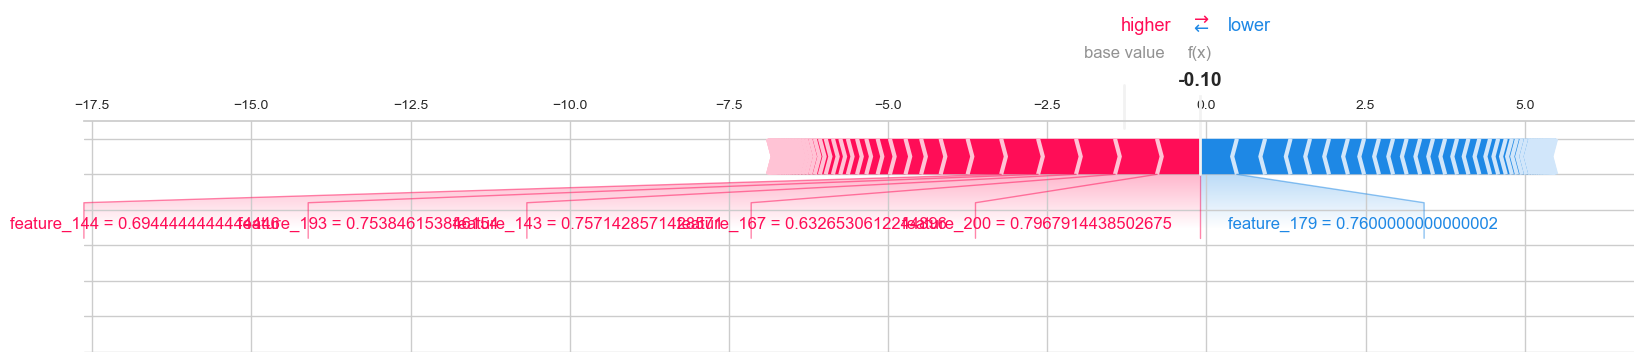


Hispanic sınıfı için en önemli 10 özellik indeksleri:
[200 167 143 193 179 144 181 174  40 176]

Hispanic sınıfı için en önemli 10 özellik isimleri:
['feature_200', 'feature_167', 'feature_143', 'feature_193', 'feature_179', 'feature_144', 'feature_181', 'feature_174', 'feature_40', 'feature_176']

Tüm özelliklerin önem sıralaması:
         feature    importance
0    feature_200  6.721493e-01
1    feature_167  6.592770e-01
2    feature_143  6.126090e-01
3    feature_193  5.957916e-01
4    feature_179  5.828555e-01
5    feature_144  5.798003e-01
6    feature_181  5.270481e-01
7    feature_174  4.429192e-01
8     feature_40  4.237722e-01
9    feature_176  3.998549e-01
10   feature_214  3.064967e-01
11   feature_203  3.055769e-01
12   feature_224  2.980241e-01
13   feature_207  2.966430e-01
14   feature_151  2.538266e-01
15   feature_147  2.451225e-01
16   feature_219  2.448625e-01
17   feature_195  2.337782e-01
18   feature_170  2.219427e-01
19   feature_114  2.135548e-01
20    feature_

In [153]:
# SHAP değerlerini hesapla
explainer = shap.Explainer(model_shap, X_train_trans)
start_index = 203
end_index = 204
shap_values = explainer(X_test_trans[start_index:end_index])

# Veri yapılarını kontrol et
print("shap_values shape:", shap_values.shape)
print("X_test_trans shape:", X_test_trans[start_index:end_index].shape)
print("explainer.expected_value shape:", np.array(explainer.expected_value).shape)
print("X.columns length:", len(X.columns))

# Tahmin edilen sınıfı al
prediction = model_shap.predict(X_test_trans[start_index:end_index])[0]
print(f"The log_model predicted: {prediction}")

# Hispanic sınıfının indeksini bul
hispanic_index = list(model_shap.classes_).index("Hispanic")

# Özellik isimlerini oluştur
feature_names = [f"feature_{i}" for i in range(X_test_trans.shape[1])]

# SHAP değerlerini görselleştir (Hispanic sınıfı için)
shap.initjs()
shap.plots.force(shap_values[0, :, hispanic_index],  # Hispanic sınıfı için SHAP değerleri
                 feature_names=feature_names,
                 matplotlib=True)

# Hispanic sınıfı için özellik önemini hesapla
feature_importance = np.abs(shap_values.values[:, :, hispanic_index]).mean(axis=0)
top_10_features = np.argsort(feature_importance)[-10:][::-1]
print("\nHispanic sınıfı için en önemli 10 özellik indeksleri:")
print(top_10_features)

# En önemli 10 özelliğin isimlerini yazdır
top_10_feature_names = [feature_names[i] for i in top_10_features]
print("\nHispanic sınıfı için en önemli 10 özellik isimleri:")
print(top_10_feature_names)

# Tüm özelliklerin önem sıralamasını göster
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTüm özelliklerin önem sıralaması:")
print(feature_importance_df)

# X ve X_test_trans arasındaki farkı kontrol et
print("\nX ve X_test_trans arasındaki fark:")
print("X shape:", X.shape)
print("X_test_trans shape:", X_test_trans.shape)
print("X columns:", X.columns.tolist())
print("X_test_trans number of features:", X_test_trans.shape[1])

# Kirmizi renkler; hangi feature' in Hispanic class' ini tahmin etmede ne kadar katkisi oldugunu gosteriyor. 
# Buyukluk ne kadar fazla ise katkisi o kadar fazla demek. 
# Renklerin altinda feature isimlerini ve degerlerini de gorebiliyoruz.

# Mavi renkler ise tahmindeki negatif etkiyi gosteriyor. 
# Yani en genis boyutta olan tahmin etmede en kotu feature. (Bu grafigi tek bir gozlem icin cizdirdik.)

In [154]:
explainer.expected_value[1]

# Hispanic class' inin ilk base degeri. 
# Yani model, butun Hispanicler icin -0.85 olasiligi ile baslayacak. (Gradient Descent' te oldugu gibi)

-1.2886214462851306

In [155]:
X_test_trans[203]

array([0.        , 1.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       1.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

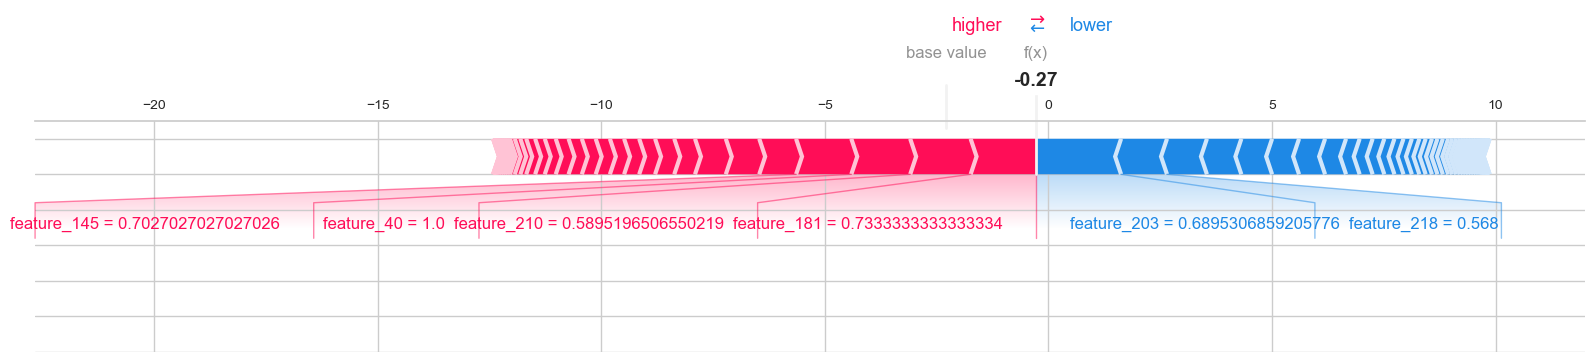

Sınıf 0 için SHAP Force Plot oluşturuldu.


In [156]:
# Force plot için SHAP değerlerini ve beklenen değeri al
shap_values_class_0 = shap_values.values[0, :, 0]
expected_value_class_0 = explainer.expected_value[0]

# Force plot oluştur
shap.plots.force(base_value=expected_value_class_0,
                 shap_values=shap_values_class_0,
                 features=X_test_trans[start_index],
                 feature_names=feature_names,
                 matplotlib=True)

print(f"Sınıf 0 için SHAP Force Plot oluşturuldu.")

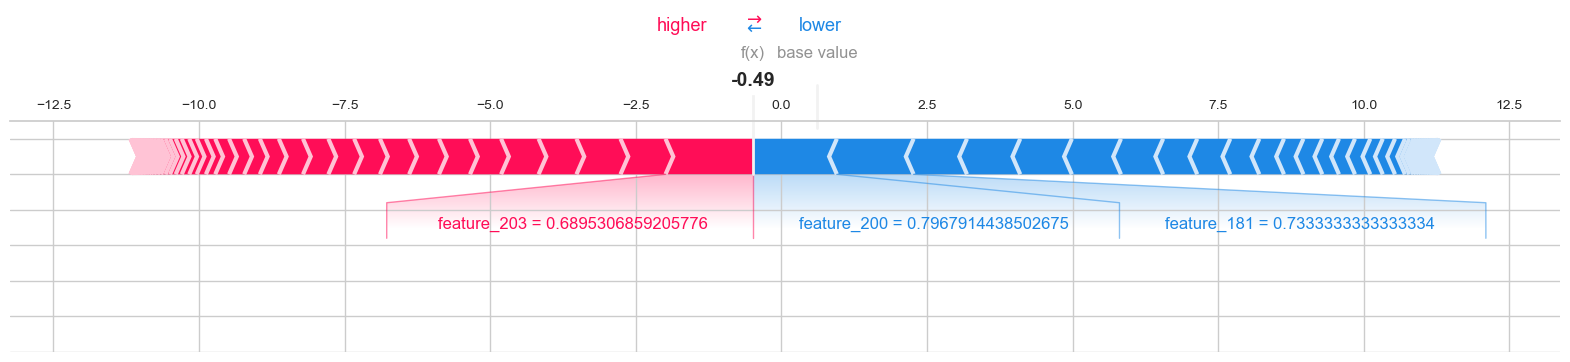

Sınıf 2 için SHAP Force Plot oluşturuldu.


In [157]:
# Force plot için SHAP değerlerini ve beklenen değeri al
shap_values_class_2 = shap_values.values[0, :, 2]
expected_value_class_2 = explainer.expected_value[2]

# Force plot oluştur
shap.plots.force(base_value=expected_value_class_2,
                 shap_values=shap_values_class_2,
                 features=X_test_trans[start_index],
                 feature_names=feature_names,
                 matplotlib=True)

print(f"Sınıf 2 için SHAP Force Plot oluşturuldu.")

**SHAP Force Plot:**
- Grafikte her bir özellik modelin tahminine ne kadar katkı sağladığını göstermektedir.
- **Base value (-0.49)**: Bu, modelin tahminine başlamadan önceki referans noktasıdır. Modelin "ortalama tahmini" diyebiliriz.
- **f(x)**: Bu nokta modelin nihai tahminidir ve referans noktasından itibaren hangi özelliklerin modeli nasıl etkilediğini gösterir.

**Özelliklerin SHAP Değerleri ve Model Tahmini:**
- **Pozitif SHAP Değerleri (mavi)**: Bu özellikler modelin tahminini sağ tarafa (pozitif yönde) iter. Yani, bu özellikler modelin tahminini pozitif yönde etkiler ve modelin tahminini bu yöne kaydırır.
- **Negatif SHAP Değerleri (kırmızı)**: Bu özellikler modelin tahminini sol tarafa (negatif yönde) iter. Yani, bu özellikler modelin tahminini azaltıcı yönde etkiler ve tahmin edilen değeri daha düşük bir sonuca çeker.

**Özelliklerin Katkıları (Görsele Göre):**
- **feature_203 (0.69)**: Bu özellik pozitif bir katkıda bulunmuş ve modelin tahminini sağ tarafa (pozitif yönde) itmiştir. Bu, modelin tahminini artırarak, tahmin edilen sınıfın olasılığını artırmıştır.
  
- **feature_200 (0.79)**: Bu özellik de pozitif bir katkıda bulunmuş ve modelin tahminini artırmıştır. Tahmin edilen sınıfın olasılığını pozitif yönde etkilemiştir.

- **feature_181 (0.73)**: Yine pozitif bir SHAP değeri olan bu özellik, tahmin edilen sınıfa yönelik modelin tahminini artırmış.

**Sonuç:**
- **Base value (-0.49)**: Modelin "başlangıç noktası" burasıdır. Model burada başlıyor ve özelliklerin katkılarına göre tahminini sağa veya sola kaydırıyor.
  
- **Pozitif SHAP değerleri (mavi)**: Bu özellikler (örneğin `feature_203`, `feature_200`, `feature_181`) modelin tahminini artırmış ve tahmin edilen sınıfa doğru itmiş. Bu durumda bu özelliklerin modelin tahminine olumlu katkı sağladığını söyleyebiliriz.

- **f(x)**: Modelin nihai tahmini buradadır ve referans noktası olan `-0.49`'dan sağa kaymış, bu da tahminin artış yönünde olduğunu gösterir.

**Özet:**
Görselde gösterilen SHAP force plot’ta, pozitif SHAP değerlerine sahip olan `feature_203`, `feature_200`, ve `feature_181` özellikleri, modelin tahminini pozitif yönde (sağa) kaydırmış. Bu özellikler, modelin belirlediği tahminin artmasına ve tahmin edilen sınıfın olasılığının yükselmesine neden olmuştur. Modelin başlangıçtaki referans değeri olan `-0.49`'dan sağa doğru kayarak tahmin edilen sınıfın olasılığı artmış.

In [158]:
print(model_shap.classes_)

['Black' 'Hispanic' 'White']


Yukarida ornek olmasi acisindan, bir gozlem icin hangi feature' in ne kadar katki sagladigina baktik. Simdi asagida butun gozlemler icin hangi feature' in tahminlemeye ne kadar etkisi var bunu gorelim :

## Shap values for all data

**Yukarida ornek olmasi acisindan, bir gozlem icin hangi feature' in ne kadar katki sagladigina baktik. Simdi asagida butun gozlemler icin hangi feature' in tahminlemeye ne kadar etkisi var bunu görelim.**

In [159]:
features = column_trans_shap.get_feature_names_out()
features

array(['onehotencoder__Gender_Female', 'onehotencoder__Gender_Male',
       'onehotencoder__SubjectsBirthLocation_Alabama',
       'onehotencoder__SubjectsBirthLocation_Alaska',
       'onehotencoder__SubjectsBirthLocation_Antigua and Barbuda',
       'onehotencoder__SubjectsBirthLocation_Argentina',
       'onehotencoder__SubjectsBirthLocation_Arizona',
       'onehotencoder__SubjectsBirthLocation_Arkansas',
       'onehotencoder__SubjectsBirthLocation_Azerbaijan',
       'onehotencoder__SubjectsBirthLocation_Bahamas',
       'onehotencoder__SubjectsBirthLocation_Barbados',
       'onehotencoder__SubjectsBirthLocation_Belarus',
       'onehotencoder__SubjectsBirthLocation_Belgium',
       'onehotencoder__SubjectsBirthLocation_Belize',
       'onehotencoder__SubjectsBirthLocation_Bermuda',
       'onehotencoder__SubjectsBirthLocation_Bolivia',
       'onehotencoder__SubjectsBirthLocation_Brazil',
       'onehotencoder__SubjectsBirthLocation_British Virgin Islands',
       'onehotencode

In [160]:
new_features = [i.replace("onehotencoder__", "").replace("remainder__","") for i in features]
new_features

['Gender_Female',
 'Gender_Male',
 'SubjectsBirthLocation_Alabama',
 'SubjectsBirthLocation_Alaska',
 'SubjectsBirthLocation_Antigua and Barbuda',
 'SubjectsBirthLocation_Argentina',
 'SubjectsBirthLocation_Arizona',
 'SubjectsBirthLocation_Arkansas',
 'SubjectsBirthLocation_Azerbaijan',
 'SubjectsBirthLocation_Bahamas',
 'SubjectsBirthLocation_Barbados',
 'SubjectsBirthLocation_Belarus',
 'SubjectsBirthLocation_Belgium',
 'SubjectsBirthLocation_Belize',
 'SubjectsBirthLocation_Bermuda',
 'SubjectsBirthLocation_Bolivia',
 'SubjectsBirthLocation_Brazil',
 'SubjectsBirthLocation_British Virgin Islands',
 'SubjectsBirthLocation_Bulgaria',
 'SubjectsBirthLocation_California',
 'SubjectsBirthLocation_Cameroon',
 'SubjectsBirthLocation_Canada',
 'SubjectsBirthLocation_Chile',
 'SubjectsBirthLocation_Colombia',
 'SubjectsBirthLocation_Colorado',
 'SubjectsBirthLocation_Connecticut',
 'SubjectsBirthLocation_Costa Rica',
 'SubjectsBirthLocation_Cuba',
 'SubjectsBirthLocation_Delaware',
 'Subjec

**Explainer ve shap_values**

shap.Explainer bir "açıklayıcı" nesnesi oluşturur. Bu nesne, bir makine öğrenimi modelinin (model_shap) tahminlerini açıklamak için kullanılır. 

Explainer nesnesi, modelin ve eğitim veri setinin (X_train_trans) özelliklerini alır ve SHAP değerlerini hesaplamak için kullanılır.

**Explainer Çeşitleri**

SHAP kütüphanesi, farklı türdeki modeller için çeşitli "Explainer" türleri sunar:

- **KernelExplainer**: Her türlü model için kullanılabilir, ancak genellikle yavaştır.
- **TreeExplainer**: Karar ağaçları, rastgele ormanlar, XGBoost, LightGBM gibi ağaç tabanlı modeller için optimize edilmiştir.
- **DeepExplainer**: Derin öğrenme modelleri için tasarlanmıştır.
- **LinearExplainer**: Lineer modeller için optimize edilmiştir.
- **ExactExplainer**: Tam ve kesin SHAP değerlerini hesaplar, ancak genellikle yavaştır.

**shap.Explainer fonksiyonu** genellikle model türüne göre en uygun "Explainer" türünü otomatik olarak seçer. Yani, eğer bir tree base model (örneğin, XGBoost veya RandomForest) verirseniz, bu genellikle TreeExplainer'ı kullanacaktır. Eğer bir derin öğrenme modeli verirseniz, DeepExplainer'ı kullanabilir. Lineer bir model için ise LinearExplainer'ı seçebilir.

Bu otomatik seçim genellikle çoğu kullanım senaryosu için yeterli olur, ancak eğer spesifik bir "Explainer" türü kullanmak istiyorsanız, bunu manuel olarak da belirtebilirsiniz.

**Logistik Regresyon için** shap.Explainer genellikle LinearExplainer'ı seçer, çünkü Logistik Regresyon bir lineer modeldir. LinearExplainer, lineer modellerin katsayılarını doğrudan kullanarak SHAP değerlerini hızlı ve etkili bir şekilde hesaplar.

Her bir "Explainer" türü, modelin yapısına ve ihtiyacınıza bağlı olarak farklı avantajlar ve dezavantajlar sunar.

In [161]:
# Shap' in icine eğitilmiş modeli ve trans edilmii olan X_train' i verdik. 
# shap_values' un icine de X_test' i verdik ki hangi feature' in class' lari tahmin etmede ne kadar etkisi var 
# bunu gozlemleyelim

# explainer = shap.LinearExplainer(model_shap, X_train_trans) 

explainer = shap.Explainer(model_shap, X_train_trans)

shap_values = explainer.shap_values(X_test_trans)

Asagida kuvvetli ilk 13 feature arasinda Hispanic class' i tespit edilememis. Bu feature' larda White ve Black' ler cok iyi tespit edilmis. Hispanic' lerin tespiti 13. feature' dan sonra baslamis. Eger Shap yerine normal feature importance yapsaydik en guclu frature' lari secmis olsaydik Hispanic class' ina ait skorlar cok kotu cikacakti. 

TypeError: only integer scalar arrays can be converted to a scalar index



In [162]:
shap.summary_plot(shap_values, X_train_trans, max_display=300,feature_names = new_features)

# Train test' i verdik ki data leakage olmasin.
# max_display=300 ----> "300 feature goster"

# Asagida kuvvetli ilk 13 feature arasinda Hispanic class' i tespit edilememis. 
# Bu feature' larda White ve Black' ler cok iyi tespit edilmis. 
# Hispanic' lerin tespiti 13. feature' dan sonra baslamis. 
# Eger Shap yerine normal feature importance yapsaydik en guclu frature' lari secmis olsaydik 
# Hispanic class' ina ait skorlar cok kotu cikacakti.

In [164]:
# Yukaridaki grafige gore, Hispanic' leri tespit etmede en cok katkisi olan feature' lar ile bir liste olusturduk.
# Data Cleaning asamasinda dogum yerleri ile ilgili olan feature' i (SubjectsBirthLocation) tutmustuk.
# Grafigi incelersek dogum yerinin Hispanic' leri tespit etmede onemli bir yer tuttugunu gorebiliriz.

hispanic = ["SubjectsBirthLocation",  'handlength',  'forearmcircumferenceflexed', "headlength", 'bitragionsubmandibulararc',
            'footbreadthhorizontal',  'bimalleolarbreadth', 'poplitealheight', 'waistdepth', 'WritingPreference', 'tragiontopofhead',
            'bideltoidbreadth', 'neckcircumferencebase', 'biacromialbreadth','buttockheight', 'buttockkneelength', 'earlength', 
            'axillaheight', "Age"]

In [165]:
# Sectigimiz feature' lar ile yeniden X ve y yi olusturup modelimizi kuracagiz 

X2 = X[hispanic]
X2.head()

,SubjectsBirthLocation,handlength,forearmcircumferenceflexed,headlength,bitragionsubmandibulararc,footbreadthhorizontal,bimalleolarbreadth,poplitealheight,waistdepth,WritingPreference,tragiontopofhead,bideltoidbreadth,neckcircumferencebase,biacromialbreadth,buttockheight,buttockkneelength,earlength,axillaheight,Age
0,North Dakota,193,299,206,291,101,71,437,240,Right hand,140,493,436,401,882,619,71,1347,41
1,New York,195,289,201,320,98,67,417,225,Left hand,120,479,420,394,870,584,62,1293,35
2,New York,203,357,202,330,103,75,431,255,Left hand,125,544,434,427,901,623,61,1327,42
3,Wisconsin,194,318,199,309,106,73,393,205,Right hand,127,518,446,401,821,560,66,1239,31
4,North Carolina,218,324,197,310,111,80,523,214,Right hand,122,524,430,435,1080,706,56,1478,21


In [166]:
cat_new = X2.select_dtypes("object").columns
cat_new

Index(['SubjectsBirthLocation', 'WritingPreference'], dtype='object')

In [167]:
X2.shape

(5769, 19)

In [168]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=101, stratify =y)

In [169]:
# Yeni belirledigimiz feature' lar ile modelimizi yeniden kurduk
# !!!! Shap' e verilen penalty="l1" olmak zorunda. l2 ile feature selection yapilmaz. !!!!

column_trans_shap = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_new), 
                                       remainder=MinMaxScaler())

operations_shap = [("OneHotEncoder",column_trans_shap),("log", LogisticRegression(class_weight='balanced',max_iter=10000,
                                                            random_state=101, penalty="l1", solver='saga'))]

pipe_shap_model = Pipeline(steps=operations_shap)
pipe_shap_model.fit(X_train2, y_train2)

Pipeline(steps=[('OneHotEncoder',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('log',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    penalty='l1', random_state=101,
                                    solver='saga'))])

Shap ile kurdugumuz bu modelde White ve Black skorlarinin da nispeten dustugunu goruyoruz bununla beraber Hispanic recall skoru yukseldi. Eger klasik yontem ile feature selection yapsaydik en cok one cikan feature' lari alacaktik, Hispanic skorlarimiz cok kotulesecekti. 

In [170]:
eval_metric(pipe_shap_model, X_train2, y_train2, X_test2, y_test2)

# Shap ile kurdugumuz bu modelde White ve Black skorlarinin da nispeten dustugunu goruyoruz.
# Bununla beraber Hispanic recall skoru yukseldi. 
# Eger klasik yontem ile feature selection yapsaydik en cok one cikan feature' lari alacaktik, 
# Hispanic skorlarimiz cok kotulesecekti.

Test_Set
[[215  15  30]
 [  8 108  20]
 [ 93 129 536]]
              precision    recall  f1-score   support

       Black       0.68      0.83      0.75       260
    Hispanic       0.43      0.79      0.56       136
       White       0.91      0.71      0.80       758

    accuracy                           0.74      1154
   macro avg       0.67      0.78      0.70      1154
weighted avg       0.80      0.74      0.76      1154


Train_Set
[[ 878   47  113]
 [  31  441   71]
 [ 366  512 2156]]
              precision    recall  f1-score   support

       Black       0.69      0.85      0.76      1038
    Hispanic       0.44      0.81      0.57       543
       White       0.92      0.71      0.80      3034

    accuracy                           0.75      4615
   macro avg       0.68      0.79      0.71      4615
weighted avg       0.81      0.75      0.77      4615



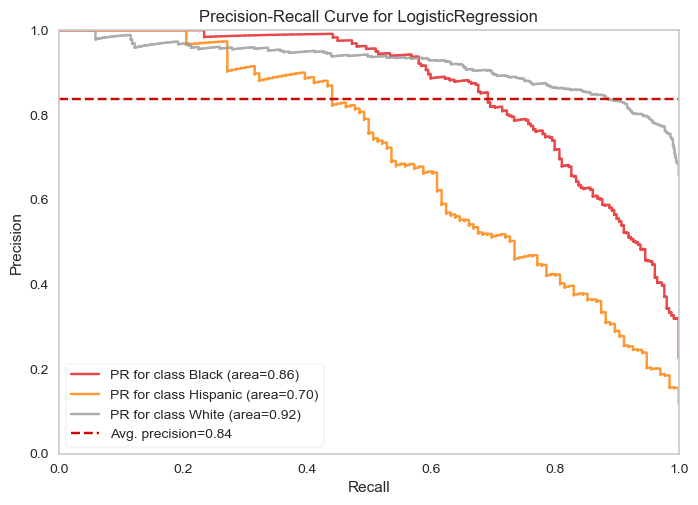

In [171]:
from yellowbrick.classifier import PrecisionRecallCurve

model = Pipeline(steps=operations_shap)

viz = PrecisionRecallCurve(
    model,
    per_class=True, 
    classes= ["Black", "Hispanic", "White"],
    cmap="Set1"
)
viz.fit(X_train2, y_train2)
viz.score(X_test2, y_test2)
viz.show();

# Shap' ten sonra PrecisionRecallCurve' de de Hispanic class' ina ait skor %70 cikmis 

Iyilestirdigimiz skora tekrar smote islemini uygulayalim :

## SMOTE for X2 dataset

- Iyilestirdigimiz skora tekrar smote islemini uygulayalim

In [172]:
column_trans = make_column_transformer((OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_new), 
                                       remainder=MinMaxScaler())

In [173]:
over = SMOTE(sampling_strategy={"Hispanic": 1200})
under = RandomUnderSampler(sampling_strategy={"White": 2500})

In [174]:
operations = [("OneHotEncoder",column_trans), ('o', over), ('u', under), 
              ("log", LogisticRegression(C=0.8, max_iter=10000, random_state=101))] 

In [175]:
smote_pipeline3 = imbpipeline(steps=operations)

In [176]:
smote_pipeline3.fit(X_train2, y_train2)    

Pipeline(steps=[('OneHotEncoder',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('o', SMOTE(sampling_strategy={'Hispanic': 1200})),
                ('u', RandomUnderSampler(sampling_strategy={'White': 2500})),
                ('log',
                 LogisticRegression(C=0.8, max_iter=10000, random_state=101))])

In [177]:
eval_metric(smote_pipeline3, X_train2, y_train2, X_test2, y_test2)

# Smote sonrası kimi skorlarda yükselme kimi skorlarda düşme gözlendi. Ayrıntılı değerlendrmek lazım.

Test_Set
[[182  10  68]
 [  4  92  40]
 [ 36  63 659]]
              precision    recall  f1-score   support

       Black       0.82      0.70      0.76       260
    Hispanic       0.56      0.68      0.61       136
       White       0.86      0.87      0.86       758

    accuracy                           0.81      1154
   macro avg       0.75      0.75      0.74      1154
weighted avg       0.81      0.81      0.81      1154


Train_Set
[[ 738   40  260]
 [  22  367  154]
 [ 131  252 2651]]
              precision    recall  f1-score   support

       Black       0.83      0.71      0.77      1038
    Hispanic       0.56      0.68      0.61       543
       White       0.86      0.87      0.87      3034

    accuracy                           0.81      4615
   macro avg       0.75      0.75      0.75      4615
weighted avg       0.82      0.81      0.82      4615



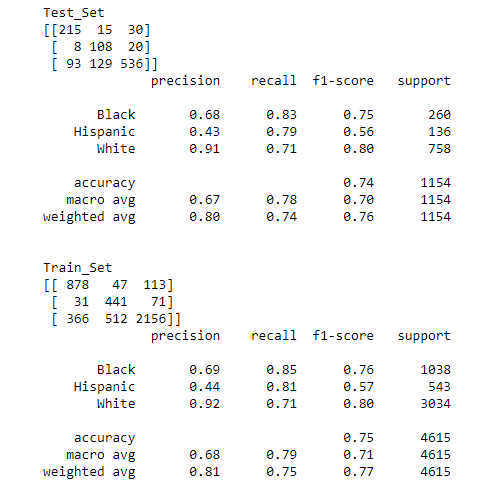